#  Deep Learning for Natural Language Processing - Exercise 2
## Author: Margarita Orfanidi Id: 7115152400023

The definition of ambiguity in the responses politicians give during interviews is a very challenging task in the field of NLP. Based on the dataset released for SemEval 2026 Task 6 (CLARITY), this assignment explores this NLP problem by fine-tuning Transformer-based architectures. Specifically, this notebook investigates the performance of DistilBERT-base-uncased for the three-class classification task, where each question-answer pair is classified as Clear Reply, Ambivalent, or Clear Non-Reply.

DistilBERT is a lighter and faster alternative to BERT, while still preserving most of its language understanding capabilities. The experiments below examine the effect of different hyperparameters, weighted loss, handling long inputs with a striding window, and additional training epochs.

## Load libraries

In [1]:
#!pip install transformers datasets torch scikit-learn sentencepiece tqdm 
# !pip uninstall -y torch torchvision torchaudio
# !pip install torch torchvision torchaudio --index-url https://download.pytorch.org/whl/cu124
# import os

# os.environ["KMP_DUPLICATE_LIB_OK"] = "TRUE"
import random
import sys
sys.path.append('/kaggle/input/datasets/leloulv/utils-exercise-2')
import sys
sys.path.append('/kaggle/input/datasets/leloulv/exercise1-nlp')
import torch
import time

import pandas as pd
import numpy as np
from torch.utils.data import DataLoader, Dataset
from transformers import AutoTokenizer, AutoModelForSequenceClassification, get_scheduler
from tqdm.auto import tqdm
from datasets import load_dataset
from torch.optim import AdamW
from transformers import DataCollatorWithPadding
import gc
import matplotlib.pyplot as plt
import seaborn as sns
import copy
from torch.utils.data import  WeightedRandomSampler
from sklearn.model_selection import StratifiedKFold
from sklearn.metrics import (
    f1_score, 
    classification_report, 
    confusion_matrix, 
    ConfusionMatrixDisplay
)

from sklearn.utils.class_weight import compute_class_weight

from utils import *
from helper_functions import *
set_seed(seed=42)

In [2]:
# Load the dataset (train and test sets)
dataset = load_dataset("ailsntua/QEvasion")
df_train = pd.DataFrame(dataset["train"])
df_test = pd.DataFrame(dataset["test"])


README.md: 0.00B [00:00, ?B/s]

data/train-00000-of-00001.parquet:   0%|          | 0.00/3.90M [00:00<?, ?B/s]

data/test-00000-of-00001.parquet:   0%|          | 0.00/259k [00:00<?, ?B/s]

Generating train split:   0%|          | 0/3448 [00:00<?, ? examples/s]

Generating test split:   0%|          | 0/308 [00:00<?, ? examples/s]

# Preprocessing

Before training, a few simple preprocessing steps were applied. First, the question and interview_answer columns in both the training and test sets were explicitly cast to string type to prevent any type-related errors during tokenization. Second, any duplicate rows, based on a combination of the question, interview_answer, and clarity_label columns, were removed from the training set, ensuring that no identical question-answer-label triplets appeared more than once. Finally, the categorical clarity_label column was mapped to numeric integer labels — Clear Reply as 0, Ambivalent as 1, and Clear Non-Reply as 2 — as PyTorch requires class labels to be represented as integers rather than strings when computing loss during training.

Additional cleaning steps, such as stop word removal, were also explored but ultimately discarded, as they did not yield any noticeable improvement and risked stripping semantically relevant content from the interview responses.

In [3]:

# Clean text columns
df_train["question"] = df_train["question"].astype(str)
df_train["interview_answer"] = df_train["interview_answer"].astype(str)

df_test["question"] = df_test["question"].astype(str)
df_test["interview_answer"] = df_test["interview_answer"].astype(str)


# size before removing duplicates
print("Before drop_duplicates:", df_train.shape)

# remove duplicated rows based on question + answer + label
df_train = df_train.drop_duplicates(subset=["question", "interview_answer", "clarity_label"]).reset_index(drop=True)

# size after removing duplicates
print("After drop_duplicates:", df_train.shape)
print("Rows removed:", df_train.shape[0])



Before drop_duplicates: (3448, 20)
After drop_duplicates: (3402, 20)
Rows removed: 3402


In [4]:


print("Original labels:", df_train['clarity_label'].unique())

label_mapping = {
    "Clear Reply": 0,
    "Ambivalent": 1,
    "Clear Non-Reply": 2
}
# Apply the mapping to both train and test dataframes
df_train['labels'] = df_train['clarity_label'].map(label_mapping)
df_test['labels'] = df_test['clarity_label'].map(label_mapping)



Original labels: ['Clear Reply' 'Ambivalent' 'Clear Non-Reply']


In [5]:
#  Create new columns
df_train["questionQ"] =("Question:"+ " " + df_train["question"] )
df_train["interview_answerA"]=("Answer:" + " " + df_train["interview_answer"])

df_test["questionQ"] =("Question:"+ " " + df_test["question"] )
df_test["interview_answerA"]=("Answer:" + " " + df_test["interview_answer"])

# Create a new column 'text' by concatenating 'question' and 'interview_answer'
df_train["text"] = ("Question:"+ " " + df_train["question"] + "Answer:" +" " + df_train["interview_answer"])
df_test ["text"] = ( "Question:"+ " " + df_test["question"] + "Answer:" + " " + df_test["interview_answer"] ) 


In [6]:
device_manager = DeviceManager()
device_manager.summary()
device = device_manager.device


print("Python exe:", sys.executable)
print("Torch version:", torch.__version__)
print("Torch CUDA build:", torch.version.cuda)
print("CUDA available:", torch.cuda.is_available())
print("GPU count:", torch.cuda.device_count())

Device type: cuda
Current GPU: Tesla T4
Using 2 GPUs with DataParallel
Python exe: /usr/bin/python3
Torch version: 2.10.0+cu128
Torch CUDA build: 12.8
CUDA available: True
GPU count: 2


In [7]:
# Model and Tokenizer
model_checkpoint = "distilbert-base-uncased"
tokenizer = AutoTokenizer.from_pretrained(model_checkpoint)


config.json:   0%|          | 0.00/483 [00:00<?, ?B/s]

tokenizer_config.json:   0%|          | 0.00/48.0 [00:00<?, ?B/s]

vocab.txt: 0.00B [00:00, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]

# Experiments

## Experiment 1: Baseline

This experiment defines the baseline training setup for the three-class classification task using DistilBERT-base-uncased. The purpose of this experiment is to establish an initial reference point against which all later configurations can be compared.

*Experimental Configuration*

The baseline configuration consists of:

- **Number of folds:** 4
- **Number of epochs:** 3
- **Batch size:** 8
- **Learning rate:** 2 × 10⁻⁵
- **Optimizer:** AdamW
- **Loss function:** Cross-entropy loss
- **Learning rate scheduler:** Linear scheduler with no warm-up steps
- **Primary evaluation metric:** Macro F1-score




 Starting Fold 1/4


model.safetensors:   0%|          | 0.00/268M [00:00<?, ?B/s]

Loading weights:   0%|          | 0/100 [00:00<?, ?it/s]

DistilBertForSequenceClassification LOAD REPORT from: distilbert-base-uncased
Key                     | Status     | 
------------------------+------------+-
vocab_transform.weight  | UNEXPECTED | 
vocab_transform.bias    | UNEXPECTED | 
vocab_layer_norm.bias   | UNEXPECTED | 
vocab_projector.bias    | UNEXPECTED | 
vocab_layer_norm.weight | UNEXPECTED | 
classifier.bias         | MISSING    | 
classifier.weight       | MISSING    | 
pre_classifier.weight   | MISSING    | 
pre_classifier.bias     | MISSING    | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING	:those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


Fold 1 Epoch 1:   0%|          | 0/319 [00:00<?, ?it/s]

...

Epoch 1: Train Loss 0.8904 | Val Loss 0.8589 | Val F1 0.2475


Fold 4 Epoch 2:   0%|          | 0/319 [00:00<?, ?it/s]

Epoch 2: Train Loss 0.8066 | Val Loss 0.7794 | Val F1 0.5598


Fold 4 Epoch 3:   0%|          | 0/319 [00:00<?, ?it/s]

Epoch 3: Train Loss 0.6649 | Val Loss 0.7541 | Val F1 0.5641

 Overall Cross Validation Results  

Average Validation F1 Score: 0.5772 ± 0.0115

Fold execution times:
Fold 1: 4.56 minutes
Fold 2: 4.68 minutes
Fold 3: 4.70 minutes
Fold 4: 4.70 minutes

Total time for all 4 folds: 18.65 minutes
Average time per fold: 4.66 minutes

 Overall Classification Report (Out-Of-Fold Predictions):
              precision    recall  f1-score   support

           0       0.63      0.33      0.43      1041
           1       0.67      0.86      0.76      2009
           2       0.60      0.50      0.55       352

    accuracy                           0.66      3402
   macro avg       0.63      0.56      0.58      3402
weighted avg       0.65      0.66      0.63      3402



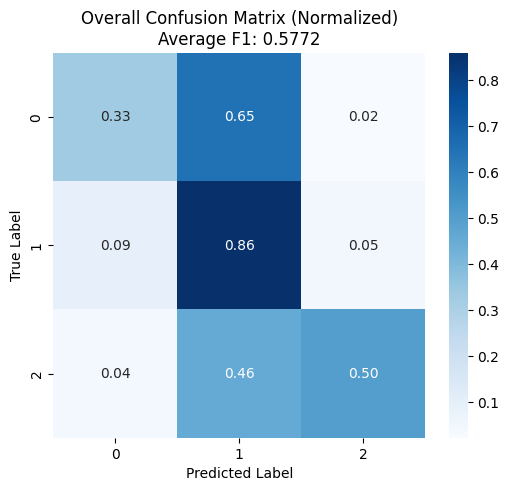


Cross-validation results
Fold F1s: [0.5888006753316377, 0.5673576218931443, 0.5883097093569722, 0.564135018421062]
Mean Macro F1: 0.5772
Std Macro F1: 0.0115


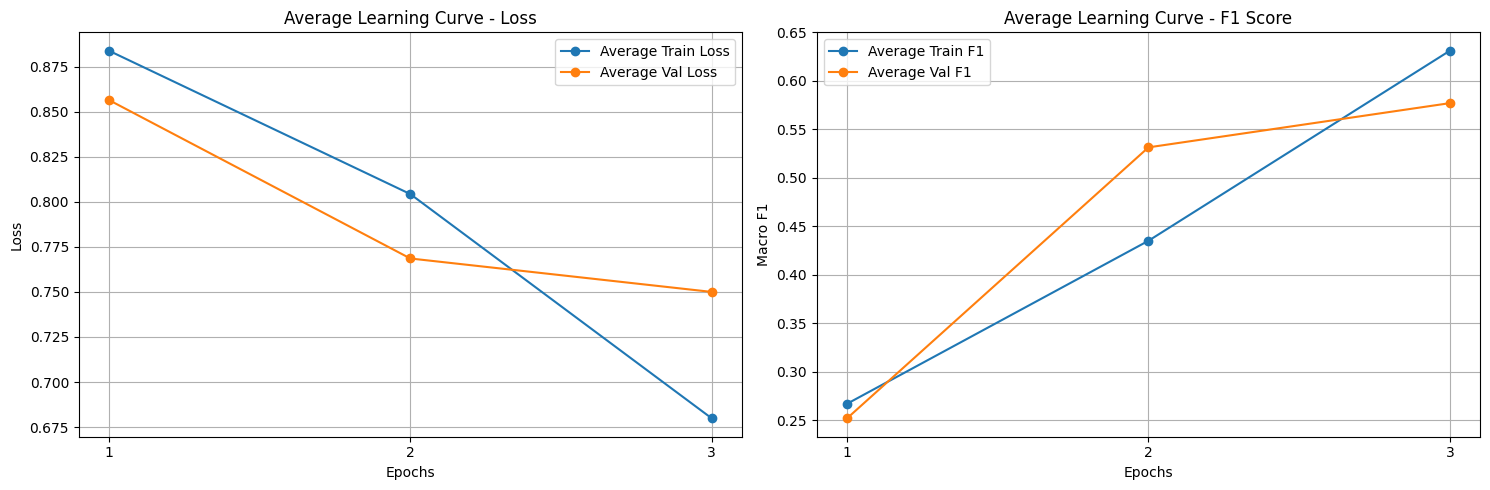

In [8]:

# ==========================================
#  Experiment 1 
# ==========================================

n_splits = 4
num_epochs = 3 # after 3 epoch is noticed overfitting
batch_size = 8
learning_rate = 2e-5


# Metrics storage
history = {'train_loss': [], 'val_loss': [], 'train_f1': [], 'val_f1': []}
fold_results = []
# Out-Of-Fold predictions
oof_preds = []
oof_labels =[]

skf = StratifiedKFold(n_splits=n_splits, shuffle=True, random_state=42)
fold_times = []
experiment_start_time = time.time()
# ==========================================
#  Cross-Validation Loop
# ==========================================
# Loop over folds

for fold, (train_idx, val_idx) in enumerate(skf.split(df_train, df_train["labels"])):
    fold_start_time = time.time()
    print(f"\n Starting Fold {fold + 1}/{n_splits}")
    
    df_train_fold = df_train.iloc[train_idx]
    df_val_fold = df_train.iloc[val_idx]
#Tokenizer
    train_encodings = tokenizer(
        list(df_train_fold["question"]),
        list(df_train_fold["interview_answer"]),
        truncation=True,
        padding=True,
        max_length=512 
    )
    val_encodings = tokenizer(
        list(df_val_fold["question"]),
        list(df_val_fold["interview_answer"]),
        truncation=True,
        padding=True,
        max_length=512
    )
 
    train_dataset = ClarityDataset(train_encodings, df_train_fold["labels"].tolist())
    val_dataset = ClarityDataset(val_encodings, df_val_fold["labels"].tolist())

    train_loader = DataLoader(
        train_dataset,
        batch_size=batch_size,
        shuffle=True 
    )

    val_loader = DataLoader(
        val_dataset,
        batch_size=batch_size,
        shuffle=False # no shuffle here
    )
# model
    model = AutoModelForSequenceClassification.from_pretrained(model_checkpoint, num_labels=3)
# for 2 gpus
    if device_manager.use_data_parallel:
        model = torch.nn.DataParallel(model)
    model.to(device)
   #optimizer
    optimizer = AdamW(model.parameters(), lr=learning_rate)
# Cross-entropy loss for multiclass classification
    loss_fn = torch.nn.CrossEntropyLoss()
# Scheduler for gradually decreasing the learning rate
    num_training_steps = num_epochs * len(train_loader)
    lr_scheduler = get_scheduler(
        name="linear", 
        optimizer=optimizer, 
        num_warmup_steps=0,  
        num_training_steps=num_training_steps
    )

    # Store training and validation loss/F1 for each epoch in the current fold

    fold_train_loss, fold_val_loss = [], []
    fold_train_f1, fold_val_f1 = [], []
    # Keep the best validation F1 score for this fold

    best_f1_fold = 0
    best_preds_fold, best_labels_fold = [], []
    # Loop over epochs
    for epoch in range(num_epochs):
        model.train()     # Set the model to training mode
        total_train_loss = 0     # Reset training loss for each epoch

        train_preds, train_labels = [], []     # Store training predictions and labels for F1 calculation

        # Training loop over batches

        for batch in tqdm(train_loader, desc=f"Fold {fold+1} Epoch {epoch+1}"):
            
            optimizer.zero_grad()         # Clear previous gradients
           
            # Move batch data to device 

            input_ids = batch['input_ids'].to(device)
            attention_mask = batch['attention_mask'].to(device)
            labels = batch['labels'].to(device)
            # Forward pass
            outputs = model(input_ids, attention_mask=attention_mask)
           
            loss = loss_fn(outputs.logits, labels) # Compute loss
            loss.backward() # Backpropagation            
            optimizer.step()# Update model parameters
            lr_scheduler.step()# Update learning rate

            total_train_loss += loss.item() # Add batch loss to total training loss
            # Store predictions and true labels for this batch
            train_preds.extend(torch.argmax(outputs.logits, dim=1).cpu().numpy())
            train_labels.extend(labels.cpu().numpy())
        # Compute average training loss for the epoch
        avg_train_loss = total_train_loss / len(train_loader)
        # Compute training macro F1 score for the epoch
        avg_train_f1 = f1_score(train_labels, train_preds, average="macro")
        
        # Set the model to evaluation mode

        model.eval()
        total_val_loss = 0 # Reset validation loss for this epoch
        val_preds, val_labels = [], [] # Store validation predictions and labels for F1 calculation
       
        # Validation loop (no gradient computation)
        with torch.no_grad():
            for batch in val_loader:
                # Move batch data to device
                input_ids = batch['input_ids'].to(device)
                attention_mask = batch['attention_mask'].to(device)
                labels = batch['labels'].to(device)
                # Forward pass
                outputs = model(input_ids, attention_mask=attention_mask)
                loss = loss_fn(outputs.logits, labels) # Compute validation loss

                total_val_loss += loss.item()# Add batch loss to total validation loss
                # Store predictions and true labels
                val_preds.extend(torch.argmax(outputs.logits, dim=1).cpu().numpy())
                val_labels.extend(labels.cpu().numpy())

        avg_val_loss = total_val_loss / len(val_loader)
        avg_val_f1 = f1_score(val_labels, val_preds, average="macro")
        
        # Save training/validation metrics for this epoch

        fold_train_loss.append(avg_train_loss)
        fold_val_loss.append(avg_val_loss)
        fold_train_f1.append(avg_train_f1)
        fold_val_f1.append(avg_val_f1)

        if avg_val_f1 > best_f1_fold:
            best_f1_fold = avg_val_f1
            best_preds_fold = val_preds
            best_labels_fold = val_labels
        
            

        print(f"Epoch {epoch+1}: Train Loss {avg_train_loss:.4f} | Val Loss {avg_val_loss:.4f} | Val F1 {avg_val_f1:.4f}")

    history['train_loss'].append(fold_train_loss)
    history['val_loss'].append(fold_val_loss)
    history['train_f1'].append(fold_train_f1)
    history['val_f1'].append(fold_val_f1)
    fold_results.append(best_f1_fold)
    oof_preds.extend(best_preds_fold)
    oof_labels.extend(best_labels_fold)
    
    fold_time = time.time() - fold_start_time
    fold_times.append(fold_time)
    del model, optimizer
    torch.cuda.empty_cache()
# ==========================================
#  OVERALL RESULTS 
# ==========================================

print("\n" + "="*50)
print(" Overall Cross Validation Results  ")
print("="*50)

mean_f1 = np.mean(fold_results)
std_f1 = np.std(fold_results)

print(f"\nAverage Validation F1 Score: {mean_f1:.4f} ± {std_f1:.4f}")

print("\nFold execution times:")
for i, fold_time in enumerate(fold_times):
    print(f"Fold {i+1}: {fold_time/60:.2f} minutes")

total_time = time.time() - experiment_start_time
mean_fold_time = np.mean(fold_times)

print(f"\nTotal time for all {n_splits} folds: {total_time/60:.2f} minutes")
print(f"Average time per fold: {mean_fold_time/60:.2f} minutes")

print("\n Overall Classification Report (Out-Of-Fold Predictions):")
print(classification_report(oof_labels, oof_preds))

plt.figure(figsize=(6, 5))
cm_overall = confusion_matrix(oof_labels, oof_preds, normalize='true')
sns.heatmap(cm_overall, annot=True, cmap='Blues', fmt='.2f')
plt.title(f"Overall Confusion Matrix (Normalized)\nAverage F1: {mean_f1:.4f}")
plt.ylabel('True Label')
plt.xlabel('Predicted Label')
plt.show()

cv_results = plot_cv_learning_curves(history, fold_results, num_epochs)



## Batch Size & Learning Rate Tuning

After establishing the baseline model, the next experiments focused on hyperparameter tuning. In particular, different batch sizes and learning rates were tested in order to examine their effect on training stability and validation performance. These parameters are important because they directly influence how fast and how effectively the model learns during fine-tuning.

### Experiment 2 
*Experimental Configuration*

- **Number of folds:** 4
- **Number of epochs:** 3
- **Batch size:** 8
- **Learning rate:** 3 × 10⁻⁵
- **Optimizer:** AdamW
- **Loss function:** Cross-entropy loss
- **Learning rate scheduler:** Linear scheduler with no warm-up steps
- **Primary evaluation metric:** Macro F1-score


 Starting Fold 1/4


Loading weights:   0%|          | 0/100 [00:00<?, ?it/s]

DistilBertForSequenceClassification LOAD REPORT from: distilbert-base-uncased
Key                     | Status     | 
------------------------+------------+-
vocab_transform.weight  | UNEXPECTED | 
vocab_transform.bias    | UNEXPECTED | 
vocab_layer_norm.bias   | UNEXPECTED | 
vocab_projector.bias    | UNEXPECTED | 
vocab_layer_norm.weight | UNEXPECTED | 
classifier.bias         | MISSING    | 
classifier.weight       | MISSING    | 
pre_classifier.weight   | MISSING    | 
pre_classifier.bias     | MISSING    | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING	:those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


Fold 1 Epoch 1:   0%|          | 0/319 [00:00<?, ?it/s]

Epoch 1: Train Loss 0.8908 | Val Loss 0.8288 | Val F1 0.3486


...

Epoch 1: Train Loss 0.8813 | Val Loss 0.8249 | Val F1 0.2932


Fold 4 Epoch 2:   0%|          | 0/319 [00:00<?, ?it/s]

Epoch 2: Train Loss 0.7680 | Val Loss 0.7668 | Val F1 0.5458


Fold 4 Epoch 3:   0%|          | 0/319 [00:00<?, ?it/s]

Epoch 3: Train Loss 0.6066 | Val Loss 0.7852 | Val F1 0.5871

 Overall Cross Validation Results  

Average Validation F1 Score: 0.5853 ± 0.0199

Fold execution times:
Fold 1: 4.69 minutes
Fold 2: 4.71 minutes
Fold 3: 4.71 minutes
Fold 4: 4.71 minutes

Total time for all 4 folds: 18.82 minutes
Average time per fold: 4.70 minutes

 Overall Classification Report (Out-Of-Fold Predictions):
              precision    recall  f1-score   support

           0       0.59      0.37      0.45      1041
           1       0.68      0.83      0.75      2009
           2       0.62      0.51      0.56       352

    accuracy                           0.66      3402
   macro avg       0.63      0.57      0.59      3402
weighted avg       0.65      0.66      0.64      3402



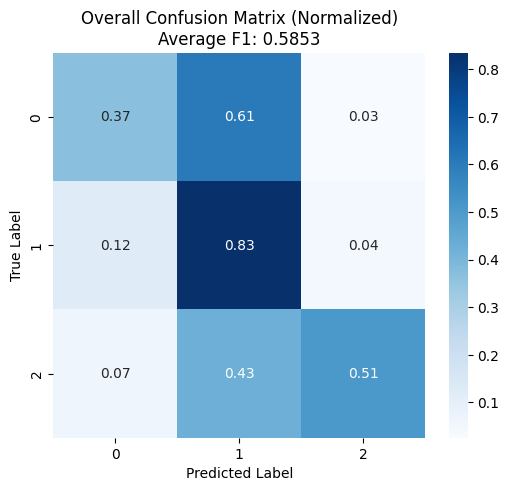


Cross-validation results
Fold F1s: [0.5952238412374883, 0.5528308789657679, 0.6061543797085166, 0.5870561250556027]
Mean Macro F1: 0.5853
Std Macro F1: 0.0199


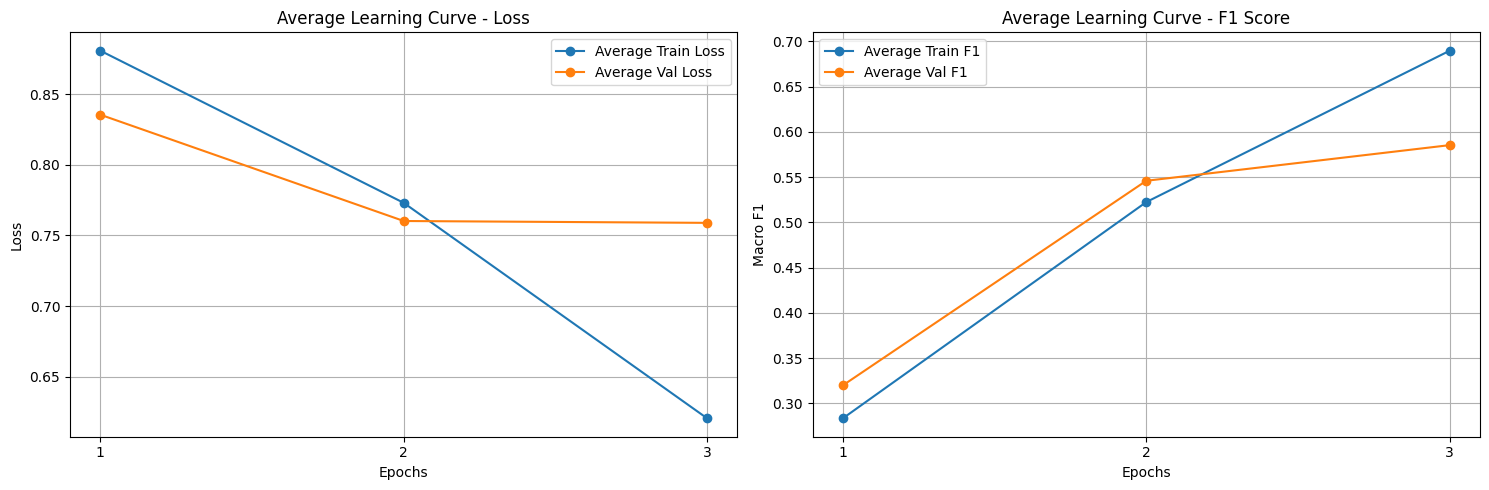

In [9]:

# ==========================================
#  Experiment 2
# ==========================================

n_splits = 4
num_epochs = 3 # after 3 epoch is noticed overfitting
batch_size = 8
learning_rate = 3e-5


# Metrics storage
history = {'train_loss': [], 'val_loss': [], 'train_f1': [], 'val_f1': []}
fold_results = []
# Out-Of-Fold predictions
oof_preds = []
oof_labels =[]

skf = StratifiedKFold(n_splits=n_splits, shuffle=True, random_state=42)
fold_times = []
experiment_start_time = time.time()
# ==========================================
#  Cross-Validation Loop
# ==========================================
# Loop over folds

for fold, (train_idx, val_idx) in enumerate(skf.split(df_train, df_train["labels"])):
    fold_start_time = time.time()
    print(f"\n Starting Fold {fold + 1}/{n_splits}")
    
    df_train_fold = df_train.iloc[train_idx]
    df_val_fold = df_train.iloc[val_idx]
#Tokenizer
    train_encodings = tokenizer(
        list(df_train_fold["question"]),
        list(df_train_fold["interview_answer"]),
        truncation=True, 
        padding=True,
        max_length=512 
    )
    val_encodings = tokenizer(
        list(df_val_fold["question"]),
        list(df_val_fold["interview_answer"]),
        truncation=True,
        padding=True,
        max_length=512
    )
 
    train_dataset = ClarityDataset(train_encodings, df_train_fold["labels"].tolist())
    val_dataset = ClarityDataset(val_encodings, df_val_fold["labels"].tolist())

    train_loader = DataLoader(
        train_dataset,
        batch_size=batch_size,
        shuffle=True 
    )

    val_loader = DataLoader(
        val_dataset,
        batch_size=batch_size,
        shuffle=False # no shuffle here
    )
# model
    model = AutoModelForSequenceClassification.from_pretrained(model_checkpoint, num_labels=3)
# for 2 gpus
    if device_manager.use_data_parallel:
        model = torch.nn.DataParallel(model)
    model.to(device)
   #optimizer
    optimizer = AdamW(model.parameters(), lr=learning_rate)
# Cross-entropy loss for multiclass classification
    loss_fn = torch.nn.CrossEntropyLoss()
# Scheduler for gradually decreasing the learning rate
    num_training_steps = num_epochs * len(train_loader)
    lr_scheduler = get_scheduler(
        name="linear", 
        optimizer=optimizer, 
        num_warmup_steps=0,  
        num_training_steps=num_training_steps
    )

    # Store training and validation loss/F1 for each epoch in the current fold

    fold_train_loss, fold_val_loss = [], []
    fold_train_f1, fold_val_f1 = [], []
    # Keep the best validation F1 score for this fold

    best_f1_fold = 0
    best_preds_fold, best_labels_fold = [], []
    # Loop over epochs
    for epoch in range(num_epochs):
        model.train()     # Set the model to training mode
        total_train_loss = 0     # Reset training loss for each epoch

        train_preds, train_labels = [], []     # Store training predictions and labels for F1 calculation

        # Training loop over batches

        for batch in tqdm(train_loader, desc=f"Fold {fold+1} Epoch {epoch+1}"):
            
            optimizer.zero_grad()         # Clear previous gradients
           
            # Move batch data to device 

            input_ids = batch['input_ids'].to(device)
            attention_mask = batch['attention_mask'].to(device)
            labels = batch['labels'].to(device)
            # Forward pass
            outputs = model(input_ids, attention_mask=attention_mask)
           
            loss = loss_fn(outputs.logits, labels) # Compute loss
            loss.backward() # Backpropagation            
            optimizer.step()# Update model parameters
            lr_scheduler.step()# Update learning rate

            total_train_loss += loss.item() # Add batch loss to total training loss
            # Store predictions and true labels for this batch
            train_preds.extend(torch.argmax(outputs.logits, dim=1).cpu().numpy())
            train_labels.extend(labels.cpu().numpy())
        # Compute average training loss for the epoch
        avg_train_loss = total_train_loss / len(train_loader)
        # Compute training macro F1 score for the epoch
        avg_train_f1 = f1_score(train_labels, train_preds, average="macro")
        
        # Set the model to evaluation mode

        model.eval()
        total_val_loss = 0 # Reset validation loss for this epoch
        val_preds, val_labels = [], [] # Store validation predictions and labels for F1 calculation
       
        # Validation loop (no gradient computation)
        with torch.no_grad():
            for batch in val_loader:
                # Move batch data to device
                input_ids = batch['input_ids'].to(device)
                attention_mask = batch['attention_mask'].to(device)
                labels = batch['labels'].to(device)
                # Forward pass
                outputs = model(input_ids, attention_mask=attention_mask)
                loss = loss_fn(outputs.logits, labels) # Compute validation loss

                total_val_loss += loss.item()# Add batch loss to total validation loss
                # Store predictions and true labels
                val_preds.extend(torch.argmax(outputs.logits, dim=1).cpu().numpy())
                val_labels.extend(labels.cpu().numpy())

        avg_val_loss = total_val_loss / len(val_loader)
        avg_val_f1 = f1_score(val_labels, val_preds, average="macro")
        
        # Save training/validation metrics for this epoch

        fold_train_loss.append(avg_train_loss)
        fold_val_loss.append(avg_val_loss)
        fold_train_f1.append(avg_train_f1)
        fold_val_f1.append(avg_val_f1)

        if avg_val_f1 > best_f1_fold:
            best_f1_fold = avg_val_f1
            best_preds_fold = val_preds
            best_labels_fold = val_labels
        
            

        print(f"Epoch {epoch+1}: Train Loss {avg_train_loss:.4f} | Val Loss {avg_val_loss:.4f} | Val F1 {avg_val_f1:.4f}")

    history['train_loss'].append(fold_train_loss)
    history['val_loss'].append(fold_val_loss)
    history['train_f1'].append(fold_train_f1)
    history['val_f1'].append(fold_val_f1)
    fold_results.append(best_f1_fold)
    oof_preds.extend(best_preds_fold)
    oof_labels.extend(best_labels_fold)
    
    fold_time = time.time() - fold_start_time
    fold_times.append(fold_time)
    del model, optimizer
    torch.cuda.empty_cache()
# ==========================================
#  OVERALL RESULTS 
# ==========================================

print("\n" + "="*50)
print(" Overall Cross Validation Results  ")
print("="*50)

mean_f1 = np.mean(fold_results)
std_f1 = np.std(fold_results)

print(f"\nAverage Validation F1 Score: {mean_f1:.4f} ± {std_f1:.4f}")

print("\nFold execution times:")
for i, fold_time in enumerate(fold_times):
    print(f"Fold {i+1}: {fold_time/60:.2f} minutes")

total_time = time.time() - experiment_start_time
mean_fold_time = np.mean(fold_times)

print(f"\nTotal time for all {n_splits} folds: {total_time/60:.2f} minutes")
print(f"Average time per fold: {mean_fold_time/60:.2f} minutes")

print("\n Overall Classification Report (Out-Of-Fold Predictions):")
print(classification_report(oof_labels, oof_preds))

plt.figure(figsize=(6, 5))
cm_overall = confusion_matrix(oof_labels, oof_preds, normalize='true')
sns.heatmap(cm_overall, annot=True, cmap='Blues', fmt='.2f')
plt.title(f"Overall Confusion Matrix (Normalized)\nAverage F1: {mean_f1:.4f}")
plt.ylabel('True Label')
plt.xlabel('Predicted Label')
plt.show()

cv_results = plot_cv_learning_curves(history, fold_results, num_epochs)



### Experiment 3
*Experimental Configuration*

- **Number of folds:** 4
- **Number of epochs:** 3
- **Batch size:** 4
- **Learning rate:** 2 × 10⁻⁵
- **Optimizer:** AdamW
- **Loss function:** Cross-entropy loss
- **Learning rate scheduler:** Linear scheduler with no warm-up steps
- **Primary evaluation metric:** Macro F1-score


 Starting Fold 1/4


Loading weights:   0%|          | 0/100 [00:00<?, ?it/s]

DistilBertForSequenceClassification LOAD REPORT from: distilbert-base-uncased
Key                     | Status     | 
------------------------+------------+-
vocab_transform.weight  | UNEXPECTED | 
vocab_transform.bias    | UNEXPECTED | 
vocab_layer_norm.bias   | UNEXPECTED | 
vocab_projector.bias    | UNEXPECTED | 
vocab_layer_norm.weight | UNEXPECTED | 
classifier.bias         | MISSING    | 
classifier.weight       | MISSING    | 
pre_classifier.weight   | MISSING    | 
pre_classifier.bias     | MISSING    | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING	:those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


Fold 1 Epoch 1:   0%|          | 0/638 [00:00<?, ?it/s]

Epoch 1: Train Loss 0.8713 | Val Loss 0.8000 | Val F1 0.5494


...

Epoch 1: Train Loss 0.8916 | Val Loss 0.8569 | Val F1 0.2475


Fold 4 Epoch 2:   0%|          | 0/638 [00:00<?, ?it/s]

Epoch 2: Train Loss 0.8206 | Val Loss 0.7768 | Val F1 0.5373


Fold 4 Epoch 3:   0%|          | 0/638 [00:00<?, ?it/s]

Epoch 3: Train Loss 0.6784 | Val Loss 0.7744 | Val F1 0.5563

 Overall Cross Validation Results  

Average Validation F1 Score: 0.5832 ± 0.0261

Fold execution times:
Fold 1: 5.86 minutes
Fold 2: 5.86 minutes
Fold 3: 5.85 minutes
Fold 4: 5.85 minutes

Total time for all 4 folds: 23.42 minutes
Average time per fold: 5.85 minutes

 Overall Classification Report (Out-Of-Fold Predictions):
              precision    recall  f1-score   support

           0       0.58      0.37      0.45      1041
           1       0.68      0.83      0.75      2009
           2       0.60      0.53      0.56       352

    accuracy                           0.65      3402
   macro avg       0.62      0.57      0.58      3402
weighted avg       0.64      0.65      0.64      3402



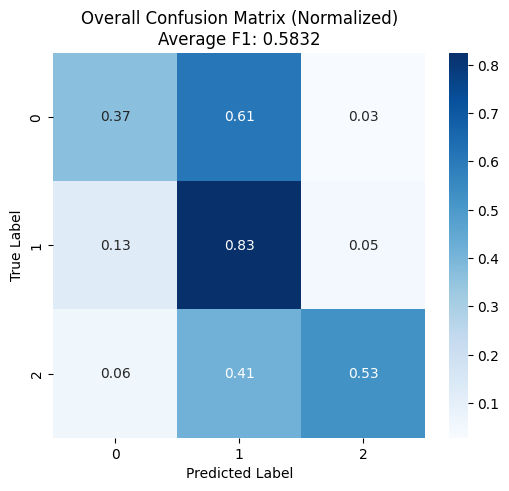


Cross-validation results
Fold F1s: [0.5881179073281758, 0.5646772967123891, 0.6237068998175727, 0.5562588637628876]
Mean Macro F1: 0.5832
Std Macro F1: 0.0261


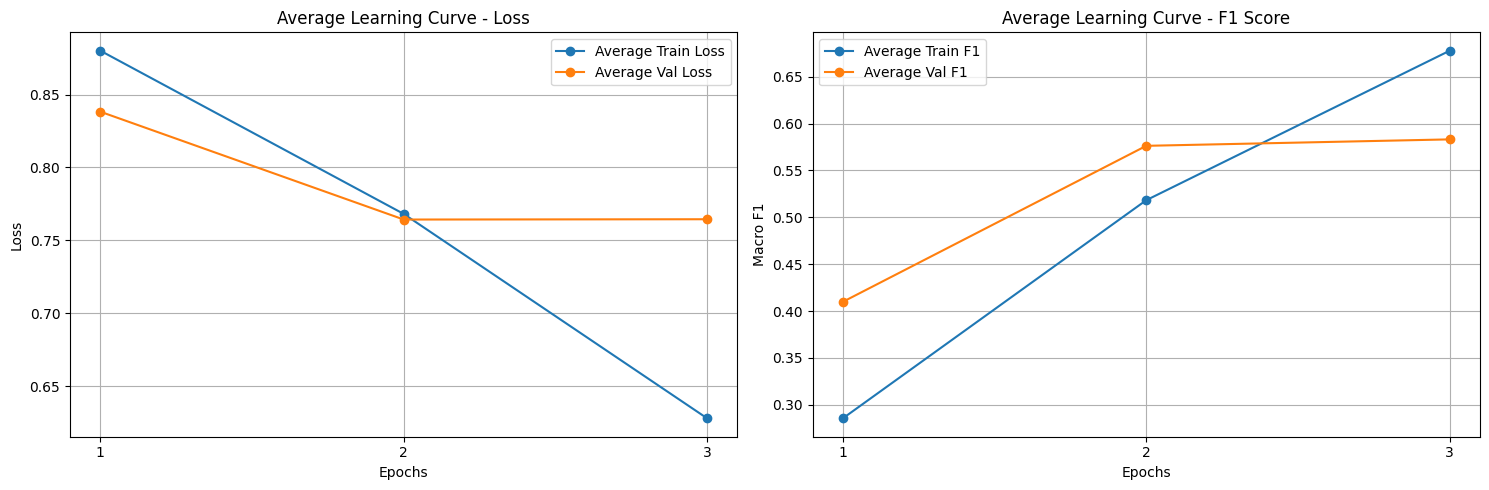

In [10]:

# ==========================================
#  Experiment 3
# ==========================================

n_splits = 4
num_epochs = 3 # after 3 epoch is noticed overfitting
batch_size = 4
learning_rate = 2e-5


# Metrics storage
history = {'train_loss': [], 'val_loss': [], 'train_f1': [], 'val_f1': []}
fold_results = []
# Out-Of-Fold predictions
oof_preds = []
oof_labels =[]

skf = StratifiedKFold(n_splits=n_splits, shuffle=True, random_state=42)
fold_times = []
experiment_start_time = time.time()
# ==========================================
#  Cross-Validation Loop
# ==========================================
# Loop over folds

for fold, (train_idx, val_idx) in enumerate(skf.split(df_train, df_train["labels"])):
    fold_start_time = time.time()
    print(f"\n Starting Fold {fold + 1}/{n_splits}")
    
    df_train_fold = df_train.iloc[train_idx]
    df_val_fold = df_train.iloc[val_idx]
#Tokenizer
    train_encodings = tokenizer(
        list(df_train_fold["question"]),
        list(df_train_fold["interview_answer"]),
        truncation=True,
        padding=True,
        max_length=512 
    )
    val_encodings = tokenizer(
        list(df_val_fold["question"]),
        list(df_val_fold["interview_answer"]),
        truncation=True,
        padding=True,
        max_length=512
    )
 
    train_dataset = ClarityDataset(train_encodings, df_train_fold["labels"].tolist())
    val_dataset = ClarityDataset(val_encodings, df_val_fold["labels"].tolist())

    train_loader = DataLoader(
        train_dataset,
        batch_size=batch_size,
        shuffle=True 
    )

    val_loader = DataLoader(
        val_dataset,
        batch_size=batch_size,
        shuffle=False # no shuffle here
    )
# model
    model = AutoModelForSequenceClassification.from_pretrained(model_checkpoint, num_labels=3)
# for 2 gpus
    if device_manager.use_data_parallel:
        model = torch.nn.DataParallel(model)
    model.to(device)
   #optimizer
    optimizer = AdamW(model.parameters(), lr=learning_rate)
# Cross-entropy loss for multiclass classification
    loss_fn = torch.nn.CrossEntropyLoss()
# Scheduler for gradually decreasing the learning rate
    num_training_steps = num_epochs * len(train_loader)
    lr_scheduler = get_scheduler(
        name="linear", 
        optimizer=optimizer, 
        num_warmup_steps=0,  
        num_training_steps=num_training_steps
    )

    # Store training and validation loss/F1 for each epoch in the current fold

    fold_train_loss, fold_val_loss = [], []
    fold_train_f1, fold_val_f1 = [], []
    # Keep the best validation F1 score for this fold

    best_f1_fold = 0
    best_preds_fold, best_labels_fold = [], []
    # Loop over epochs
    for epoch in range(num_epochs):
        model.train()     # Set the model to training mode
        total_train_loss = 0     # Reset training loss for each epoch

        train_preds, train_labels = [], []     # Store training predictions and labels for F1 calculation

        # Training loop over batches

        for batch in tqdm(train_loader, desc=f"Fold {fold+1} Epoch {epoch+1}"):
            
            optimizer.zero_grad()         # Clear previous gradients
           
            # Move batch data to device 

            input_ids = batch['input_ids'].to(device)
            attention_mask = batch['attention_mask'].to(device)
            labels = batch['labels'].to(device)
            # Forward pass
            outputs = model(input_ids, attention_mask=attention_mask)
           
            loss = loss_fn(outputs.logits, labels) # Compute loss
            loss.backward() # Backpropagation            
            optimizer.step()# Update model parameters
            lr_scheduler.step()# Update learning rate

            total_train_loss += loss.item() # Add batch loss to total training loss
            # Store predictions and true labels for this batch
            train_preds.extend(torch.argmax(outputs.logits, dim=1).cpu().numpy())
            train_labels.extend(labels.cpu().numpy())
        # Compute average training loss for the epoch
        avg_train_loss = total_train_loss / len(train_loader)
        # Compute training macro F1 score for the epoch
        avg_train_f1 = f1_score(train_labels, train_preds, average="macro")
        
        # Set the model to evaluation mode

        model.eval()
        total_val_loss = 0 # Reset validation loss for this epoch
        val_preds, val_labels = [], [] # Store validation predictions and labels for F1 calculation
       
        # Validation loop (no gradient computation)
        with torch.no_grad():
            for batch in val_loader:
                # Move batch data to device
                input_ids = batch['input_ids'].to(device)
                attention_mask = batch['attention_mask'].to(device)
                labels = batch['labels'].to(device)
                # Forward pass
                outputs = model(input_ids, attention_mask=attention_mask)
                loss = loss_fn(outputs.logits, labels) # Compute validation loss

                total_val_loss += loss.item()# Add batch loss to total validation loss
                # Store predictions and true labels
                val_preds.extend(torch.argmax(outputs.logits, dim=1).cpu().numpy())
                val_labels.extend(labels.cpu().numpy())

        avg_val_loss = total_val_loss / len(val_loader)
        avg_val_f1 = f1_score(val_labels, val_preds, average="macro")
        
        # Save training/validation metrics for this epoch

        fold_train_loss.append(avg_train_loss)
        fold_val_loss.append(avg_val_loss)
        fold_train_f1.append(avg_train_f1)
        fold_val_f1.append(avg_val_f1)

        if avg_val_f1 > best_f1_fold:
            best_f1_fold = avg_val_f1
            best_preds_fold = val_preds
            best_labels_fold = val_labels
        
            

        print(f"Epoch {epoch+1}: Train Loss {avg_train_loss:.4f} | Val Loss {avg_val_loss:.4f} | Val F1 {avg_val_f1:.4f}")

    history['train_loss'].append(fold_train_loss)
    history['val_loss'].append(fold_val_loss)
    history['train_f1'].append(fold_train_f1)
    history['val_f1'].append(fold_val_f1)
    fold_results.append(best_f1_fold)
    oof_preds.extend(best_preds_fold)
    oof_labels.extend(best_labels_fold)
    
    fold_time = time.time() - fold_start_time
    fold_times.append(fold_time)
    del model, optimizer
    torch.cuda.empty_cache()
# ==========================================
#  OVERALL RESULTS 
# ==========================================

print("\n" + "="*50)
print(" Overall Cross Validation Results  ")
print("="*50)

mean_f1 = np.mean(fold_results)
std_f1 = np.std(fold_results)

print(f"\nAverage Validation F1 Score: {mean_f1:.4f} ± {std_f1:.4f}")

print("\nFold execution times:")
for i, fold_time in enumerate(fold_times):
    print(f"Fold {i+1}: {fold_time/60:.2f} minutes")

total_time = time.time() - experiment_start_time
mean_fold_time = np.mean(fold_times)

print(f"\nTotal time for all {n_splits} folds: {total_time/60:.2f} minutes")
print(f"Average time per fold: {mean_fold_time/60:.2f} minutes")

print("\n Overall Classification Report (Out-Of-Fold Predictions):")
print(classification_report(oof_labels, oof_preds))

plt.figure(figsize=(6, 5))
cm_overall = confusion_matrix(oof_labels, oof_preds, normalize='true')
sns.heatmap(cm_overall, annot=True, cmap='Blues', fmt='.2f')
plt.title(f"Overall Confusion Matrix (Normalized)\nAverage F1: {mean_f1:.4f}")
plt.ylabel('True Label')
plt.xlabel('Predicted Label')
plt.show()

cv_results = plot_cv_learning_curves(history, fold_results, num_epochs)



### Experiment 4 
*Experimental Configuration*

- **Number of folds:** 4
- **Number of epochs:** 3
- **Batch size:** 4
- **Learning rate:** 3 × 10⁻⁵
- **Optimizer:** AdamW
- **Loss function:** Cross-entropy loss
- **Learning rate scheduler:** Linear scheduler with no warm-up steps
- **Primary evaluation metric:** Macro F1-score



 Starting Fold 1/4


Loading weights:   0%|          | 0/100 [00:00<?, ?it/s]

DistilBertForSequenceClassification LOAD REPORT from: distilbert-base-uncased
Key                     | Status     | 
------------------------+------------+-
vocab_transform.weight  | UNEXPECTED | 
vocab_transform.bias    | UNEXPECTED | 
vocab_layer_norm.bias   | UNEXPECTED | 
vocab_projector.bias    | UNEXPECTED | 
vocab_layer_norm.weight | UNEXPECTED | 
classifier.bias         | MISSING    | 
classifier.weight       | MISSING    | 
pre_classifier.weight   | MISSING    | 
pre_classifier.bias     | MISSING    | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING	:those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


Fold 1 Epoch 1:   0%|          | 0/638 [00:00<?, ?it/s]

Epoch 1: Train Loss 0.8814 | Val Loss 0.8213 | Val F1 0.3222


...

Epoch 1: Train Loss 0.8713 | Val Loss 0.8213 | Val F1 0.4398


Fold 4 Epoch 2:   0%|          | 0/638 [00:00<?, ?it/s]

Epoch 2: Train Loss 0.7300 | Val Loss 0.7564 | Val F1 0.5340


Fold 4 Epoch 3:   0%|          | 0/638 [00:00<?, ?it/s]

Epoch 3: Train Loss 0.5498 | Val Loss 0.7589 | Val F1 0.5847

 Overall Cross Validation Results  

Average Validation F1 Score: 0.5933 ± 0.0177

Fold execution times:
Fold 1: 5.85 minutes
Fold 2: 5.84 minutes
Fold 3: 5.84 minutes
Fold 4: 5.85 minutes

Total time for all 4 folds: 23.39 minutes
Average time per fold: 5.85 minutes

 Overall Classification Report (Out-Of-Fold Predictions):
              precision    recall  f1-score   support

           0       0.63      0.37      0.46      1041
           1       0.69      0.85      0.76      2009
           2       0.61      0.52      0.56       352

    accuracy                           0.67      3402
   macro avg       0.64      0.58      0.59      3402
weighted avg       0.66      0.67      0.65      3402



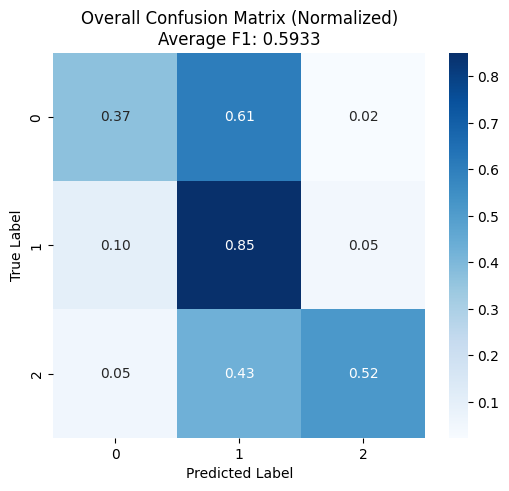


Cross-validation results
Fold F1s: [0.6006646374224912, 0.570200123470684, 0.6176465962566758, 0.5847395284007141]
Mean Macro F1: 0.5933
Std Macro F1: 0.0177


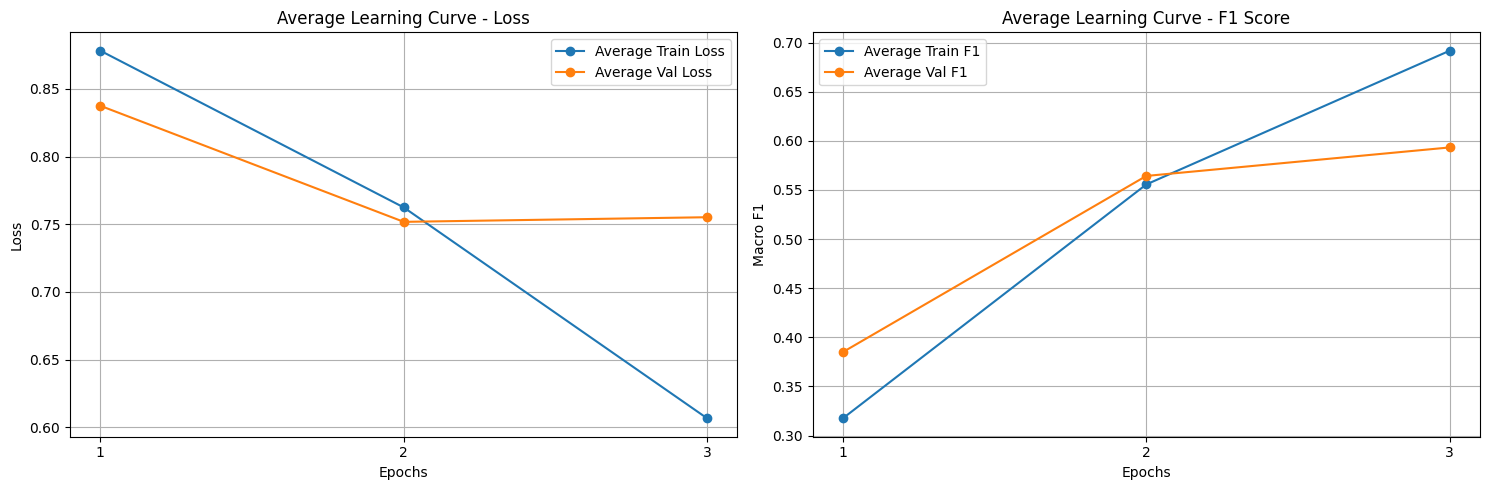

In [18]:

# ==========================================
#  Experiment 4
# ==========================================

n_splits = 4
num_epochs = 3 # after 3 epoch is noticed overfitting
batch_size = 4
learning_rate = 3e-5


# Metrics storage
history = {'train_loss': [], 'val_loss': [], 'train_f1': [], 'val_f1': []}
fold_results = []
# Out-Of-Fold predictions
oof_preds = []
oof_labels =[]

skf = StratifiedKFold(n_splits=n_splits, shuffle=True, random_state=42)
fold_times = []
experiment_start_time = time.time()
# ==========================================
#  Cross-Validation Loop
# ==========================================
# Loop over folds

for fold, (train_idx, val_idx) in enumerate(skf.split(df_train, df_train["labels"])):
    fold_start_time = time.time()
    print(f"\n Starting Fold {fold + 1}/{n_splits}")
    
    df_train_fold = df_train.iloc[train_idx]
    df_val_fold = df_train.iloc[val_idx]
#Tokenizer
    train_encodings = tokenizer(
        list(df_train_fold["question"]),
        list(df_train_fold["interview_answer"]),
        truncation=True, 
        padding=True,
        max_length=512 
    )
    val_encodings = tokenizer(
        list(df_val_fold["question"]),
        list(df_val_fold["interview_answer"]),
        truncation=True,
        padding=True,
        max_length=512
    )
 
    train_dataset = ClarityDataset(train_encodings, df_train_fold["labels"].tolist())
    val_dataset = ClarityDataset(val_encodings, df_val_fold["labels"].tolist())

    train_loader = DataLoader(
        train_dataset,
        batch_size=batch_size,
        shuffle=True 
    )

    val_loader = DataLoader(
        val_dataset,
        batch_size=batch_size,
        shuffle=False # no shuffle here
    )
# model
    model = AutoModelForSequenceClassification.from_pretrained(model_checkpoint, num_labels=3)
# for 2 gpus
    if device_manager.use_data_parallel:
        model = torch.nn.DataParallel(model)
    model.to(device)
   #optimizer
    optimizer = AdamW(model.parameters(), lr=learning_rate)
# Cross-entropy loss for multiclass classification
    loss_fn = torch.nn.CrossEntropyLoss()
# Scheduler for gradually decreasing the learning rate
    num_training_steps = num_epochs * len(train_loader)
    lr_scheduler = get_scheduler(
        name="linear", 
        optimizer=optimizer, 
        num_warmup_steps=0,  
        num_training_steps=num_training_steps
    )

    # Store training and validation loss/F1 for each epoch in the current fold

    fold_train_loss, fold_val_loss = [], []
    fold_train_f1, fold_val_f1 = [], []
    # Keep the best validation F1 score for this fold

    best_f1_fold = 0
    best_preds_fold, best_labels_fold = [], []
    # Loop over epochs
    for epoch in range(num_epochs):
        model.train()     # Set the model to training mode
        total_train_loss = 0     # Reset training loss for each epoch

        train_preds, train_labels = [], []     # Store training predictions and labels for F1 calculation

        # Training loop over batches

        for batch in tqdm(train_loader, desc=f"Fold {fold+1} Epoch {epoch+1}"):
            
            optimizer.zero_grad()         # Clear previous gradients
           
            # Move batch data to device 

            input_ids = batch['input_ids'].to(device)
            attention_mask = batch['attention_mask'].to(device)
            labels = batch['labels'].to(device)
            # Forward pass
            outputs = model(input_ids, attention_mask=attention_mask)
           
            loss = loss_fn(outputs.logits, labels) # Compute loss
            loss.backward() # Backpropagation            
            optimizer.step()# Update model parameters
            lr_scheduler.step()# Update learning rate

            total_train_loss += loss.item() # Add batch loss to total training loss
            # Store predictions and true labels for this batch
            train_preds.extend(torch.argmax(outputs.logits, dim=1).cpu().numpy())
            train_labels.extend(labels.cpu().numpy())
        # Compute average training loss for the epoch
        avg_train_loss = total_train_loss / len(train_loader)
        # Compute training macro F1 score for the epoch
        avg_train_f1 = f1_score(train_labels, train_preds, average="macro")
        
        # Set the model to evaluation mode

        model.eval()
        total_val_loss = 0 # Reset validation loss for this epoch
        val_preds, val_labels = [], [] # Store validation predictions and labels for F1 calculation
       
        # Validation loop (no gradient computation)
        with torch.no_grad():
            for batch in val_loader:
                # Move batch data to device
                input_ids = batch['input_ids'].to(device)
                attention_mask = batch['attention_mask'].to(device)
                labels = batch['labels'].to(device)
                # Forward pass
                outputs = model(input_ids, attention_mask=attention_mask)
                loss = loss_fn(outputs.logits, labels) # Compute validation loss

                total_val_loss += loss.item()# Add batch loss to total validation loss
                # Store predictions and true labels
                val_preds.extend(torch.argmax(outputs.logits, dim=1).cpu().numpy())
                val_labels.extend(labels.cpu().numpy())

        avg_val_loss = total_val_loss / len(val_loader)
        avg_val_f1 = f1_score(val_labels, val_preds, average="macro")
        
        # Save training/validation metrics for this epoch

        fold_train_loss.append(avg_train_loss)
        fold_val_loss.append(avg_val_loss)
        fold_train_f1.append(avg_train_f1)
        fold_val_f1.append(avg_val_f1)

        if avg_val_f1 > best_f1_fold:
            best_f1_fold = avg_val_f1
            best_preds_fold = val_preds
            best_labels_fold = val_labels
        
            

        print(f"Epoch {epoch+1}: Train Loss {avg_train_loss:.4f} | Val Loss {avg_val_loss:.4f} | Val F1 {avg_val_f1:.4f}")

    history['train_loss'].append(fold_train_loss)
    history['val_loss'].append(fold_val_loss)
    history['train_f1'].append(fold_train_f1)
    history['val_f1'].append(fold_val_f1)
    fold_results.append(best_f1_fold)
    oof_preds.extend(best_preds_fold)
    oof_labels.extend(best_labels_fold)
    
    fold_time = time.time() - fold_start_time
    fold_times.append(fold_time)
    del model, optimizer
    torch.cuda.empty_cache()
# ==========================================
#  OVERALL RESULTS 
# ==========================================

print("\n" + "="*50)
print(" Overall Cross Validation Results  ")
print("="*50)

mean_f1 = np.mean(fold_results)
std_f1 = np.std(fold_results)

print(f"\nAverage Validation F1 Score: {mean_f1:.4f} ± {std_f1:.4f}")

print("\nFold execution times:")
for i, fold_time in enumerate(fold_times):
    print(f"Fold {i+1}: {fold_time/60:.2f} minutes")

total_time = time.time() - experiment_start_time
mean_fold_time = np.mean(fold_times)

print(f"\nTotal time for all {n_splits} folds: {total_time/60:.2f} minutes")
print(f"Average time per fold: {mean_fold_time/60:.2f} minutes")

print("\n Overall Classification Report (Out-Of-Fold Predictions):")
print(classification_report(oof_labels, oof_preds))

plt.figure(figsize=(6, 5))
cm_overall = confusion_matrix(oof_labels, oof_preds, normalize='true')
sns.heatmap(cm_overall, annot=True, cmap='Blues', fmt='.2f')
plt.title(f"Overall Confusion Matrix (Normalized)\nAverage F1: {mean_f1:.4f}")
plt.ylabel('True Label')
plt.xlabel('Predicted Label')
plt.show()

cv_results = plot_cv_learning_curves(history, fold_results, num_epochs)



### Experiment 5
*Experimental Configuration*

- **Number of folds:** 4
- **Number of epochs:** 3
- **Batch size:** 16
- **Learning rate:** 3 × 10⁻⁵
- **Optimizer:** AdamW
- **Loss function:** Cross-entropy loss
- **Learning rate scheduler:** Linear scheduler with no warm-up steps
- **Primary evaluation metric:** Macro F1-score


 Starting Fold 1/4


Loading weights:   0%|          | 0/100 [00:00<?, ?it/s]

DistilBertForSequenceClassification LOAD REPORT from: distilbert-base-uncased
Key                     | Status     | 
------------------------+------------+-
vocab_transform.weight  | UNEXPECTED | 
vocab_transform.bias    | UNEXPECTED | 
vocab_layer_norm.bias   | UNEXPECTED | 
vocab_projector.bias    | UNEXPECTED | 
vocab_layer_norm.weight | UNEXPECTED | 
classifier.bias         | MISSING    | 
classifier.weight       | MISSING    | 
pre_classifier.weight   | MISSING    | 
pre_classifier.bias     | MISSING    | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING	:those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


Fold 1 Epoch 1:   0%|          | 0/160 [00:00<?, ?it/s]

Epoch 1: Train Loss 0.8804 | Val Loss 0.8139 | Val F1 0.3726


...

Epoch 1: Train Loss 0.8971 | Val Loss 0.8625 | Val F1 0.2475


Fold 4 Epoch 2:   0%|          | 0/160 [00:00<?, ?it/s]

Epoch 2: Train Loss 0.8367 | Val Loss 0.7955 | Val F1 0.4861


Fold 4 Epoch 3:   0%|          | 0/160 [00:00<?, ?it/s]

Epoch 3: Train Loss 0.7322 | Val Loss 0.7662 | Val F1 0.5364

 Overall Cross Validation Results  

Average Validation F1 Score: 0.5657 ± 0.0368

Fold execution times:
Fold 1: 4.12 minutes
Fold 2: 4.14 minutes
Fold 3: 4.14 minutes
Fold 4: 4.14 minutes

Total time for all 4 folds: 16.54 minutes
Average time per fold: 4.13 minutes

 Overall Classification Report (Out-Of-Fold Predictions):
              precision    recall  f1-score   support

           0       0.61      0.33      0.42      1041
           1       0.67      0.86      0.75      2009
           2       0.61      0.47      0.53       352

    accuracy                           0.66      3402
   macro avg       0.63      0.55      0.57      3402
weighted avg       0.65      0.66      0.63      3402



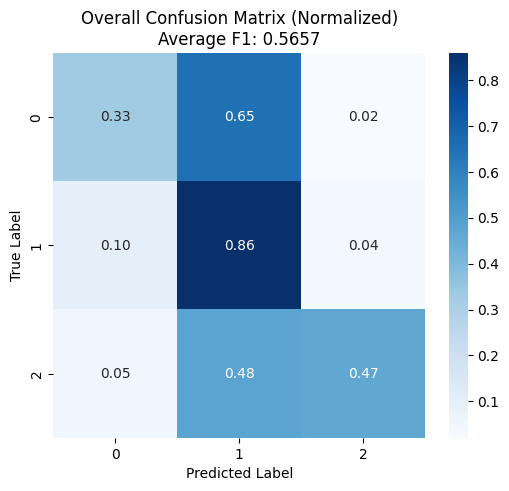


Cross-validation results
Fold F1s: [0.5958668149040046, 0.5226145222601636, 0.607989710594754, 0.5364023749093131]
Mean Macro F1: 0.5657
Std Macro F1: 0.0368


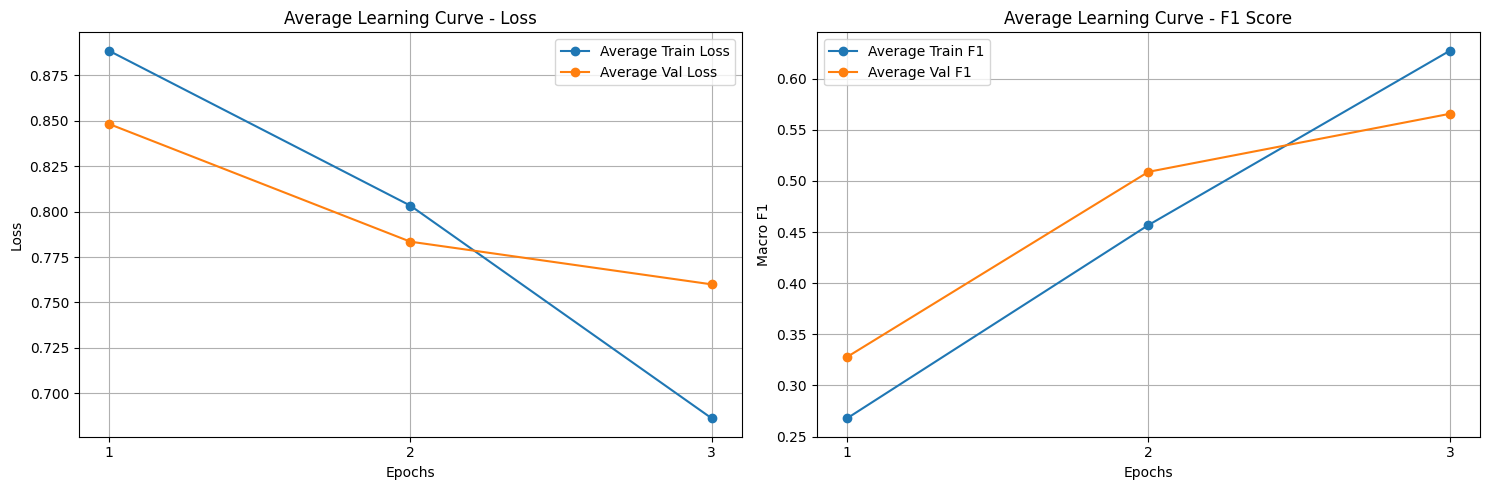

In [19]:

# ==========================================
#  Experiment 5
# ==========================================

n_splits = 4
num_epochs = 3 # after 3 epoch is noticed overfitting
batch_size = 16
learning_rate = 3e-5


# Metrics storage
history = {'train_loss': [], 'val_loss': [], 'train_f1': [], 'val_f1': []}
fold_results = []
# Out-Of-Fold predictions
oof_preds = []
oof_labels =[]

skf = StratifiedKFold(n_splits=n_splits, shuffle=True, random_state=42)
fold_times = []
experiment_start_time = time.time()
# ==========================================
#  Cross-Validation Loop
# ==========================================
# Loop over folds

for fold, (train_idx, val_idx) in enumerate(skf.split(df_train, df_train["labels"])):
    fold_start_time = time.time()
    print(f"\n Starting Fold {fold + 1}/{n_splits}")
    
    df_train_fold = df_train.iloc[train_idx]
    df_val_fold = df_train.iloc[val_idx]
#Tokenizer
    train_encodings = tokenizer(
        list(df_train_fold["question"]),
        list(df_train_fold["interview_answer"]),
        truncation=True, 
        padding=True,
        max_length=512 
    )
    val_encodings = tokenizer(
        list(df_val_fold["question"]),
        list(df_val_fold["interview_answer"]),
        truncation=True,
        padding=True,
        max_length=512
    )
 
    train_dataset = ClarityDataset(train_encodings, df_train_fold["labels"].tolist())
    val_dataset = ClarityDataset(val_encodings, df_val_fold["labels"].tolist())

    train_loader = DataLoader(
        train_dataset,
        batch_size=batch_size,
        shuffle=True 
    )

    val_loader = DataLoader(
        val_dataset,
        batch_size=batch_size,
        shuffle=False # no shuffle here
    )
# model
    model = AutoModelForSequenceClassification.from_pretrained(model_checkpoint, num_labels=3)
# for 2 gpus
    if device_manager.use_data_parallel:
        model = torch.nn.DataParallel(model)
    model.to(device)
   #optimizer
    optimizer = AdamW(model.parameters(), lr=learning_rate)
# Cross-entropy loss for multiclass classification
    loss_fn = torch.nn.CrossEntropyLoss()
# Scheduler for gradually decreasing the learning rate
    num_training_steps = num_epochs * len(train_loader)
    lr_scheduler = get_scheduler(
        name="linear", 
        optimizer=optimizer, 
        num_warmup_steps=0,  
        num_training_steps=num_training_steps
    )

    # Store training and validation loss/F1 for each epoch in the current fold

    fold_train_loss, fold_val_loss = [], []
    fold_train_f1, fold_val_f1 = [], []
    # Keep the best validation F1 score for this fold

    best_f1_fold = 0
    best_preds_fold, best_labels_fold = [], []
    # Loop over epochs
    for epoch in range(num_epochs):
        model.train()     # Set the model to training mode
        total_train_loss = 0     # Reset training loss for each epoch

        train_preds, train_labels = [], []     # Store training predictions and labels for F1 calculation

        # Training loop over batches

        for batch in tqdm(train_loader, desc=f"Fold {fold+1} Epoch {epoch+1}"):
            
            optimizer.zero_grad()         # Clear previous gradients
           
            # Move batch data to device 

            input_ids = batch['input_ids'].to(device)
            attention_mask = batch['attention_mask'].to(device)
            labels = batch['labels'].to(device)
            # Forward pass
            outputs = model(input_ids, attention_mask=attention_mask)
           
            loss = loss_fn(outputs.logits, labels) # Compute loss
            loss.backward() # Backpropagation            
            optimizer.step()# Update model parameters
            lr_scheduler.step()# Update learning rate

            total_train_loss += loss.item() # Add batch loss to total training loss
            # Store predictions and true labels for this batch
            train_preds.extend(torch.argmax(outputs.logits, dim=1).cpu().numpy())
            train_labels.extend(labels.cpu().numpy())
        # Compute average training loss for the epoch
        avg_train_loss = total_train_loss / len(train_loader)
        # Compute training macro F1 score for the epoch
        avg_train_f1 = f1_score(train_labels, train_preds, average="macro")
        
        # Set the model to evaluation mode

        model.eval()
        total_val_loss = 0 # Reset validation loss for this epoch
        val_preds, val_labels = [], [] # Store validation predictions and labels for F1 calculation
       
        # Validation loop (no gradient computation)
        with torch.no_grad():
            for batch in val_loader:
                # Move batch data to device
                input_ids = batch['input_ids'].to(device)
                attention_mask = batch['attention_mask'].to(device)
                labels = batch['labels'].to(device)
                # Forward pass
                outputs = model(input_ids, attention_mask=attention_mask)
                loss = loss_fn(outputs.logits, labels) # Compute validation loss

                total_val_loss += loss.item()# Add batch loss to total validation loss
                # Store predictions and true labels
                val_preds.extend(torch.argmax(outputs.logits, dim=1).cpu().numpy())
                val_labels.extend(labels.cpu().numpy())

        avg_val_loss = total_val_loss / len(val_loader)
        avg_val_f1 = f1_score(val_labels, val_preds, average="macro")
        
        # Save training/validation metrics for this epoch

        fold_train_loss.append(avg_train_loss)
        fold_val_loss.append(avg_val_loss)
        fold_train_f1.append(avg_train_f1)
        fold_val_f1.append(avg_val_f1)

        if avg_val_f1 > best_f1_fold:
            best_f1_fold = avg_val_f1
            best_preds_fold = val_preds
            best_labels_fold = val_labels
        
            

        print(f"Epoch {epoch+1}: Train Loss {avg_train_loss:.4f} | Val Loss {avg_val_loss:.4f} | Val F1 {avg_val_f1:.4f}")

    history['train_loss'].append(fold_train_loss)
    history['val_loss'].append(fold_val_loss)
    history['train_f1'].append(fold_train_f1)
    history['val_f1'].append(fold_val_f1)
    fold_results.append(best_f1_fold)
    oof_preds.extend(best_preds_fold)
    oof_labels.extend(best_labels_fold)
    
    fold_time = time.time() - fold_start_time
    fold_times.append(fold_time)
    del model, optimizer
    torch.cuda.empty_cache()
# ==========================================
#  OVERALL RESULTS 
# ==========================================

print("\n" + "="*50)
print(" Overall Cross Validation Results  ")
print("="*50)

mean_f1 = np.mean(fold_results)
std_f1 = np.std(fold_results)

print(f"\nAverage Validation F1 Score: {mean_f1:.4f} ± {std_f1:.4f}")

print("\nFold execution times:")
for i, fold_time in enumerate(fold_times):
    print(f"Fold {i+1}: {fold_time/60:.2f} minutes")

total_time = time.time() - experiment_start_time
mean_fold_time = np.mean(fold_times)

print(f"\nTotal time for all {n_splits} folds: {total_time/60:.2f} minutes")
print(f"Average time per fold: {mean_fold_time/60:.2f} minutes")

print("\n Overall Classification Report (Out-Of-Fold Predictions):")
print(classification_report(oof_labels, oof_preds))

plt.figure(figsize=(6, 5))
cm_overall = confusion_matrix(oof_labels, oof_preds, normalize='true')
sns.heatmap(cm_overall, annot=True, cmap='Blues', fmt='.2f')
plt.title(f"Overall Confusion Matrix (Normalized)\nAverage F1: {mean_f1:.4f}")
plt.ylabel('True Label')
plt.xlabel('Predicted Label')
plt.show()

cv_results = plot_cv_learning_curves(history, fold_results, num_epochs)



#### Conclusion

The experiments with learning rate and batch size showed that hyperparameter tuning improved the DistilBERT baseline. Increasing only the learning rate from $2 \times 10^{-5}$ to $3 \times 10^{-5}$ improved the mean macro F1-score from **0.5772** to **0.5853**. Reducing only the batch size from 8 to 4 also improved performance, reaching a mean macro F1-score of **0.5832**.

The best result among the batch size and learning rate experiments was obtained in Experiment 4, where both changes were applied together. Using batch size 4 and learning rate $3 \times 10^{-5}$ achieved a mean macro F1-score of **0.5933**, making it the strongest non-weighted configuration up to this point.


##  Handling Class Imbalance with Weighted Loss

Observations from the previous confusion matrices show that the model tends to confuse the minority classes with the majority class. In particular, many samples from the Clear Reply and Clear Non-Reply classes are classified as Ambivalent, which indicates that the class imbalance affects the model's ability to distinguish the less frequent categories.

To address this issue, a class-weighted Cross-Entropy Loss function was introduced. The goal of this experiment was to penalize mistakes on the minority classes more strongly and examine whether this would improve the macro F1-score, which gives equal importance to all classes.

The experiment used the best hyperparameter setup from the previous section, namely batch size 4 and learning rate $3 \times 10^{-5}$, combined with manually selected class weights.


#### Experiment 6
- **Number of folds:** 4
- **Number of epochs:** 3
- **Batch size:** 4
- **Learning rate:** 3 × 10⁻⁵
- **Optimizer:** AdamW
- **Loss function:** Cross-entropy loss 
- **Learning rate scheduler:** Linear scheduler
- **Primary evaluation metric:** Macro F1-score
- **Class Weights:** [1.4,1,1.5]



 Starting Fold 1/4
Class weights: [1.4 1.  1.5]


model.safetensors:   0%|          | 0.00/268M [00:00<?, ?B/s]

Loading weights:   0%|          | 0/100 [00:00<?, ?it/s]

DistilBertForSequenceClassification LOAD REPORT from: distilbert-base-uncased
Key                     | Status     | 
------------------------+------------+-
vocab_layer_norm.weight | UNEXPECTED | 
vocab_layer_norm.bias   | UNEXPECTED | 
vocab_transform.weight  | UNEXPECTED | 
vocab_transform.bias    | UNEXPECTED | 
vocab_projector.bias    | UNEXPECTED | 
classifier.bias         | MISSING    | 
pre_classifier.weight   | MISSING    | 
pre_classifier.bias     | MISSING    | 
classifier.weight       | MISSING    | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING	:those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


Fold 1 Epoch 1:   0%|          | 0/638 [00:00<?, ?it/s]

...

Epoch 1: Train Loss 0.9172 | Val Loss 0.8250 | Val F1 0.5538


Fold 4 Epoch 2:   0%|          | 0/638 [00:00<?, ?it/s]

Epoch 2: Train Loss 0.7795 | Val Loss 0.8194 | Val F1 0.5515


Fold 4 Epoch 3:   0%|          | 0/638 [00:00<?, ?it/s]

Epoch 3: Train Loss 0.6244 | Val Loss 0.8260 | Val F1 0.5505

 Overall Cross Validation Results  

Average Validation F1 Score: 0.5890 ± 0.0208

Fold execution times:
Fold 1: 6.05 minutes
Fold 2: 6.04 minutes
Fold 3: 6.04 minutes
Fold 4: 6.05 minutes

Total time for all 4 folds: 24.18 minutes
Average time per fold: 6.04 minutes

 Overall Classification Report (Out-Of-Fold Predictions):
              precision    recall  f1-score   support

           0       0.55      0.40      0.46      1041
           1       0.68      0.79      0.73      2009
           2       0.61      0.55      0.57       352

    accuracy                           0.65      3402
   macro avg       0.61      0.58      0.59      3402
weighted avg       0.63      0.65      0.63      3402



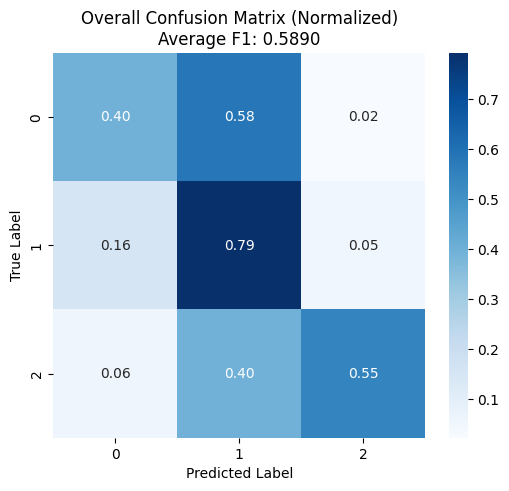


Cross-validation results
Fold F1s: [0.6074361625381819, 0.5949285250437721, 0.5996739979643807, 0.553794088650727]
Mean Macro F1: 0.5890
Std Macro F1: 0.0208


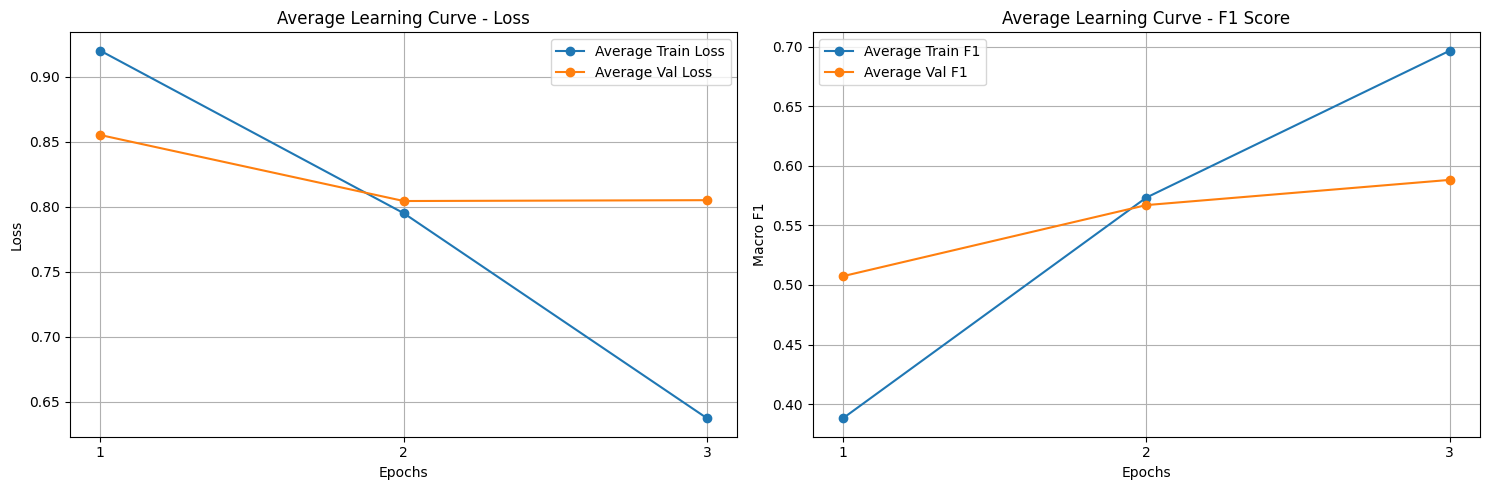

In [8]:

# ==========================================
#  Experiment 6
# ==========================================

n_splits = 4
num_epochs = 3
batch_size = 4
learning_rate = 3e-5


# Metrics storage
history = {'train_loss': [], 'val_loss': [], 'train_f1': [], 'val_f1': []}
fold_results = []
# Out-Of-Fold predictions
oof_preds = []
oof_labels =[]

skf = StratifiedKFold(n_splits=n_splits, shuffle=True, random_state=42)
fold_times = []
experiment_start_time = time.time()
# ==========================================
#  Cross-Validation Loop
# ==========================================
# Loop over folds

for fold, (train_idx, val_idx) in enumerate(skf.split(df_train, df_train["labels"])):
    fold_start_time = time.time()
    print(f"\n Starting Fold {fold + 1}/{n_splits}")
    
    df_train_fold = df_train.iloc[train_idx]
    df_val_fold = df_train.iloc[val_idx]
#Tokenizer
    train_encodings = tokenizer(
        list(df_train_fold["question"]),
        list(df_train_fold["interview_answer"]),
        truncation=True, # beacause as we saw at the token analysis there are many rows with larger that 512 tokens
        padding=True,
        max_length=512 # beacuse most of the tokens are grater that 512 
    )
    val_encodings = tokenizer(
        list(df_val_fold["question"]),
        list(df_val_fold["interview_answer"]),
        truncation=True,
        padding=True,
        max_length=512
    )
 
    train_dataset = ClarityDataset(train_encodings, df_train_fold["labels"].tolist())
    val_dataset = ClarityDataset(val_encodings, df_val_fold["labels"].tolist())

    train_loader = DataLoader(
        train_dataset,
        batch_size=batch_size,
        shuffle=True 
    )

    val_loader = DataLoader(
        val_dataset,
        batch_size=batch_size,
        shuffle=False # no shuffle here
    )
    # class weights
    class_weights = torch.tensor([1.4, 1, 1.5] , dtype=torch.float).to(device)
    print("Class weights:", class_weights.detach().cpu().numpy())

    # model
    model = AutoModelForSequenceClassification.from_pretrained(model_checkpoint, num_labels=3)
    # for 2 gpus
    if device_manager.use_data_parallel:
        model = torch.nn.DataParallel(model)
    model.to(device)
   #optimizer
    optimizer = AdamW(model.parameters(), lr=learning_rate)
# Cross-entropy loss for multiclass classification and class weights
    loss_fn = torch.nn.CrossEntropyLoss(weight=class_weights)
# Scheduler for gradually decreasing the learning rate
    num_training_steps = num_epochs * len(train_loader)
    lr_scheduler = get_scheduler(
        name="linear", 
        optimizer=optimizer, 
        num_warmup_steps=0,  
        num_training_steps=num_training_steps
    )

    # Store training and validation loss/F1 for each epoch in the current fold

    fold_train_loss, fold_val_loss = [], []
    fold_train_f1, fold_val_f1 = [], []
    # Keep the best validation F1 score for this fold

    best_f1_fold = 0
    best_preds_fold, best_labels_fold = [], []
    # Loop over epochs
    for epoch in range(num_epochs):
        model.train()     # Set the model to training mode
        total_train_loss = 0     # Reset training loss for each epoch

        train_preds, train_labels = [], []     # Store training predictions and labels for F1 calculation

        # Training loop over batches

        for batch in tqdm(train_loader, desc=f"Fold {fold+1} Epoch {epoch+1}"):
            
            optimizer.zero_grad()         # Clear previous gradients
           
            # Move batch data to device 

            input_ids = batch['input_ids'].to(device)
            attention_mask = batch['attention_mask'].to(device)
            labels = batch['labels'].to(device)
            # Forward pass
            outputs = model(input_ids, attention_mask=attention_mask)

            loss = loss_fn(outputs.logits, labels) # Compute loss
            loss.backward() # Backpropagation            
            optimizer.step()# Update model parameters
            lr_scheduler.step()# Update learning rate

            total_train_loss += loss.item() # Add batch loss to total training loss
            # Store predictions and true labels for this batch
            train_preds.extend(torch.argmax(outputs.logits, dim=1).cpu().numpy())
            train_labels.extend(labels.cpu().numpy())
        # Compute average training loss for the epoch
        avg_train_loss = total_train_loss / len(train_loader)
        # Compute training macro F1 score for the epoch
        avg_train_f1 = f1_score(train_labels, train_preds, average="macro")
        
        # Set the model to evaluation mode

        model.eval()
        total_val_loss = 0 # Reset validation loss for this epoch
        val_preds, val_labels = [], [] # Store validation predictions and labels for F1 calculation
       
        # Validation loop (no gradient computation)
        with torch.no_grad():
            for batch in val_loader:
                # Move batch data to device
                input_ids = batch['input_ids'].to(device)
                attention_mask = batch['attention_mask'].to(device)
                labels = batch['labels'].to(device)
                # Forward pass
                outputs = model(input_ids, attention_mask=attention_mask)
                loss = loss_fn(outputs.logits, labels) # Compute validation loss

                total_val_loss += loss.item()# Add batch loss to total validation loss
                # Store predictions and true labels
                val_preds.extend(torch.argmax(outputs.logits, dim=1).cpu().numpy())
                val_labels.extend(labels.cpu().numpy())

        avg_val_loss = total_val_loss / len(val_loader)
        avg_val_f1 = f1_score(val_labels, val_preds, average="macro")
        
        # Save training/validation metrics for this epoch

        fold_train_loss.append(avg_train_loss)
        fold_val_loss.append(avg_val_loss)
        fold_train_f1.append(avg_train_f1)
        fold_val_f1.append(avg_val_f1)

        if avg_val_f1 > best_f1_fold:
            best_f1_fold = avg_val_f1
            best_preds_fold = val_preds
            best_labels_fold = val_labels
        
            

        print(f"Epoch {epoch+1}: Train Loss {avg_train_loss:.4f} | Val Loss {avg_val_loss:.4f} | Val F1 {avg_val_f1:.4f}")

    history['train_loss'].append(fold_train_loss)
    history['val_loss'].append(fold_val_loss)
    history['train_f1'].append(fold_train_f1)
    history['val_f1'].append(fold_val_f1)
    fold_results.append(best_f1_fold)
    oof_preds.extend(best_preds_fold)
    oof_labels.extend(best_labels_fold)
    
    fold_time = time.time() - fold_start_time
    fold_times.append(fold_time)
    del model, optimizer
    torch.cuda.empty_cache()
# ==========================================
#  OVERALL RESULTS 
# ==========================================

print("\n" + "="*50)
print(" Overall Cross Validation Results  ")
print("="*50)

mean_f1 = np.mean(fold_results)
std_f1 = np.std(fold_results)

print(f"\nAverage Validation F1 Score: {mean_f1:.4f} ± {std_f1:.4f}")

print("\nFold execution times:")
for i, fold_time in enumerate(fold_times):
    print(f"Fold {i+1}: {fold_time/60:.2f} minutes")

total_time = time.time() - experiment_start_time
mean_fold_time = np.mean(fold_times)

print(f"\nTotal time for all {n_splits} folds: {total_time/60:.2f} minutes")
print(f"Average time per fold: {mean_fold_time/60:.2f} minutes")

print("\n Overall Classification Report (Out-Of-Fold Predictions):")
print(classification_report(oof_labels, oof_preds))

plt.figure(figsize=(6, 5))
cm_overall = confusion_matrix(oof_labels, oof_preds, normalize='true')
sns.heatmap(cm_overall, annot=True, cmap='Blues', fmt='.2f')
plt.title(f"Overall Confusion Matrix (Normalized)\nAverage F1: {mean_f1:.4f}")
plt.ylabel('True Label')
plt.xlabel('Predicted Label')
plt.show()

cv_results = plot_cv_learning_curves(history, fold_results, num_epochs)



#### Conclusion

The weighted-loss experiment achieved a mean macro F1-score of **0.5890**, which is lower than the best previous configuration from Experiment 4 (**0.5933**). Although the weighted loss was introduced to slightly improve the classification of the minority classes, it did not lead to an overall improvement in macro F1-score.

Nevertheless, the confusion matrix shows a small improvement for the minority classes. The number of misclassified samples decreased from **61 to 58** for one minority class and from **43 to 40** for the other minority class. This indicates that the weighted loss helped the model classify a few more minority-class instances correctly.

However, this improvement was limited and did not compensate for the overall decrease in macro F1-score. Therefore, while weighted loss slightly improved minority-class sensitivity, the non-weighted configuration from Experiment 4 remained the strongest configuration at this stage.

## Handling Long Inputs with Striding Window
The striding-window experiment was introduced in order to handle longer question-answer pairs more effectively. Instead of truncating each input directly to the model's maximum sequence length, the text was split into overlapping segments using a maximum length of 512 tokens and a stride of 128 tokens. The goal was to preserve more contextual information from long inputs and examine whether this additional context could improve classification performance.



#### Experiment 7
- **Number of folds:** 4
- **Number of epochs:** 3
- **Batch size:** 8
- **Learning rate:** 2 × 10⁻⁵
- **Optimizer:** AdamW
- **Loss function:** Cross-entropy loss
- **Learning rate scheduler:** Linear scheduler with 10% warm-up steps
- **Input handling:** Striding window with max length 512 and stride 128
- **Primary evaluation metric:** Macro F1-score



 Starting Fold 1/4


Loading weights:   0%|          | 0/100 [00:00<?, ?it/s]

DistilBertForSequenceClassification LOAD REPORT from: distilbert-base-uncased
Key                     | Status     | 
------------------------+------------+-
vocab_transform.weight  | UNEXPECTED | 
vocab_transform.bias    | UNEXPECTED | 
vocab_layer_norm.bias   | UNEXPECTED | 
vocab_projector.bias    | UNEXPECTED | 
vocab_layer_norm.weight | UNEXPECTED | 
classifier.bias         | MISSING    | 
classifier.weight       | MISSING    | 
pre_classifier.weight   | MISSING    | 
pre_classifier.bias     | MISSING    | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING	:those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


Fold 1 Epoch 1:   0%|          | 0/466 [00:00<?, ?it/s]

Epoch 1: Train Loss 0.8402 | Val Loss 0.8024 | Val F1 0.2474


...

Epoch 1: Train Loss 0.8358 | Val Loss 0.8126 | Val F1 0.2475


Fold 4 Epoch 2:   0%|          | 0/472 [00:00<?, ?it/s]

Epoch 2: Train Loss 0.7560 | Val Loss 0.7708 | Val F1 0.5149


Fold 4 Epoch 3:   0%|          | 0/472 [00:00<?, ?it/s]

Epoch 3: Train Loss 0.6555 | Val Loss 0.7693 | Val F1 0.5589

 Overall Cross Validation Results (Per Sample) 

Average Validation F1 Score: 0.5619 ± 0.0100

 Overall Classification Report (Out-Of-Fold):
              precision    recall  f1-score   support

           0       0.54      0.36      0.43      1041
           1       0.67      0.80      0.73      2009
           2       0.57      0.49      0.53       352

    accuracy                           0.64      3402
   macro avg       0.59      0.55      0.56      3402
weighted avg       0.62      0.64      0.62      3402



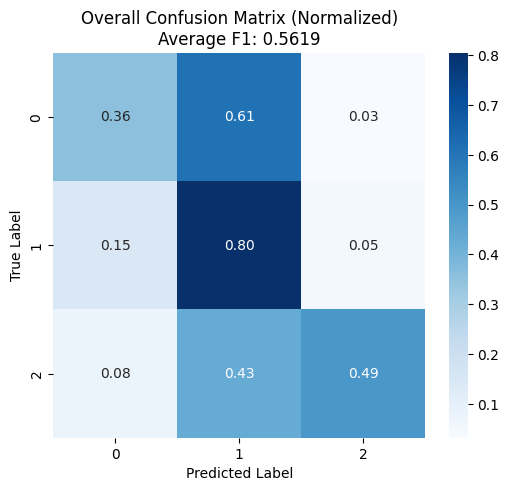


Cross-validation results
Fold F1s: [0.5700963301605225, 0.5468614565718403, 0.5719574587383645, 0.558882577666183]
Mean Macro F1: 0.5619
Std Macro F1: 0.0100


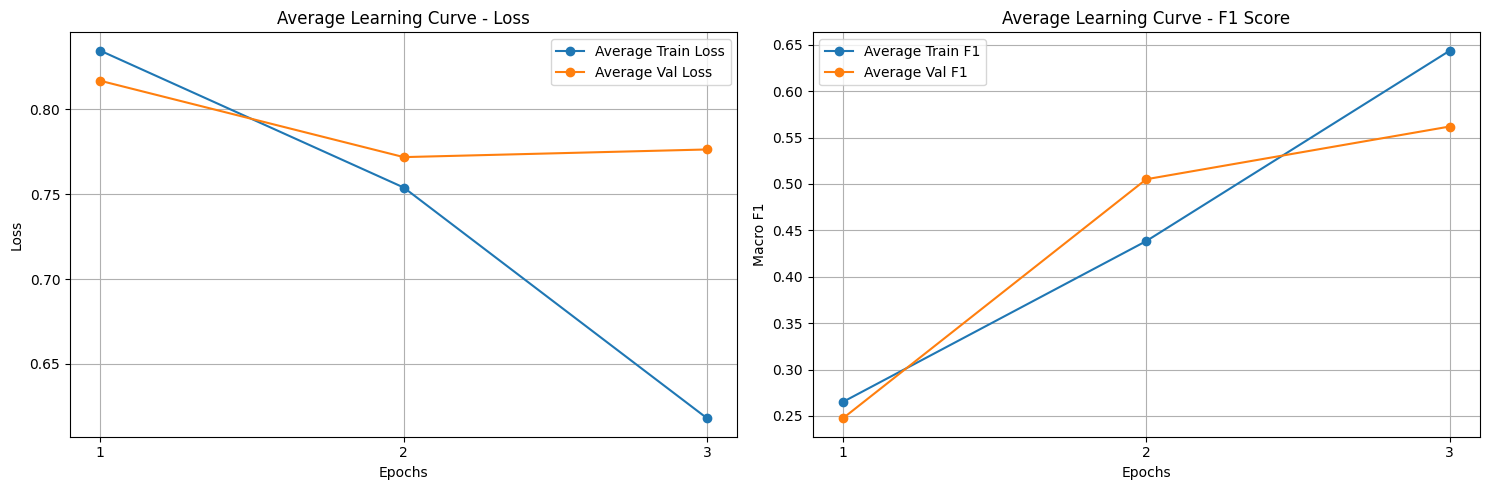

In [ ]:
from collections import Counter


# =========================================
#  Experiment 7
# ==========================================

n_splits = 4
num_epochs = 3 
batch_size = 8
learning_rate = 2e-5
max_length = 512
stride = 128  # lenght of stride window

# Metrics storage
history = {'train_loss': [], 'val_loss': [], 'train_f1': [], 'val_f1': []}
fold_results = []
oof_preds = []
oof_labels = []

skf = StratifiedKFold(n_splits=n_splits, shuffle=True, random_state=42)

# ==========================================
#  Cross-Validation Loop
# ==========================================

for fold, (train_idx, val_idx) in enumerate(skf.split(df_train, df_train["labels"])):
    print(f"\n Starting Fold {fold + 1}/{n_splits}")
    
    df_train_fold = df_train.iloc[train_idx].reset_index(drop=True)
    df_val_fold = df_train.iloc[val_idx].reset_index(drop=True)

  # --- Tokenization with Sliding Window ---
    # If an interview answer is longer than max_length,
    # it is split into multiple overlapping chunks.
    # truncation="only_second" means that only the answer is split/truncated,
    # while the question remains the same for every chunk.
    train_encodings = tokenizer(
        list(df_train_fold["question"]),
        list(df_train_fold["interview_answer"]),
        truncation="only_second",
        padding="max_length",
        max_length=max_length,
        stride=stride,
        return_overflowing_tokens=True
    )
    
     # Maps each generated chunk back to the original training sample.
    # This is needed because one sample can produce multiple chunks.
    train_sample_map = train_encodings.pop("overflow_to_sample_mapping")
     # Each chunk gets the label of its original sample.

    train_labels_expanded = [df_train_fold["labels"].iloc[i] for i in train_sample_map]

    val_encodings = tokenizer(
        list(df_val_fold["question"]),
        list(df_val_fold["interview_answer"]),
        truncation="only_second",
        padding="max_length",
        max_length=max_length,
        stride=stride,
        return_overflowing_tokens=True
    )
     #Keeps track of which validation sample each chunk belongs to.
    # Later, chunk predictions will be combined back into sample predictions.
    val_sample_map = val_encodings.pop("overflow_to_sample_mapping")

    # --- Datasets and Loaders ---
    train_dataset = ClarityDataset(train_encodings, train_labels_expanded)
    val_dataset = ClarityDataset(val_encodings, [df_val_fold["labels"].iloc[i] for i in val_sample_map])

    train_loader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True)
    val_loader = DataLoader(val_dataset, batch_size=batch_size, shuffle=False)

    # --- Model Setup ---
    model = AutoModelForSequenceClassification.from_pretrained(model_checkpoint, num_labels=3)
    if device_manager.use_data_parallel:
        model = torch.nn.DataParallel(model)
    model.to(device)

    optimizer = AdamW(model.parameters(), lr=learning_rate)
    loss_fn = torch.nn.CrossEntropyLoss()

    num_training_steps = num_epochs * len(train_loader)
    lr_scheduler = get_scheduler(
        name="linear", 
        optimizer=optimizer, 
        num_warmup_steps=int(0.1 * num_training_steps),  
        num_training_steps=num_training_steps
    )

    fold_train_loss, fold_val_loss = [], []
    fold_train_f1, fold_val_f1 = [], []
    best_f1_fold = 0
    best_preds_fold, best_labels_fold = [], []

    # --- Training Loop ---
    for epoch in range(num_epochs):
        model.train()
        total_train_loss = 0
        train_preds, train_labels = [], []

        for batch in tqdm(train_loader, desc=f"Fold {fold+1} Epoch {epoch+1}"):
            optimizer.zero_grad()
            input_ids = batch['input_ids'].to(device)
            attention_mask = batch['attention_mask'].to(device)
            labels = batch['labels'].to(device)

            outputs = model(input_ids, attention_mask=attention_mask)
            loss = loss_fn(outputs.logits, labels)
            
            loss.backward()
            optimizer.step()
            lr_scheduler.step()

            total_train_loss += loss.item()
            train_preds.extend(torch.argmax(outputs.logits, dim=1).cpu().numpy())
            train_labels.extend(labels.cpu().numpy())

        # --- Validation Loop ---
        model.eval()
        total_val_loss = 0
        val_chunk_preds = []

        with torch.no_grad():
            for batch in val_loader:
                input_ids = batch['input_ids'].to(device)
                attention_mask = batch['attention_mask'].to(device)
                labels = batch['labels'].to(device)

                outputs = model(input_ids, attention_mask=attention_mask)
                loss = loss_fn(outputs.logits, labels)
                total_val_loss += loss.item()
                val_chunk_preds.extend(torch.argmax(outputs.logits, dim=1).cpu().numpy())

         # --- Aggregate: Chunk level -> Sample level ---
        # The model predicts one label for each chunk.
        # Since one original sample may have many chunks,
        # we group all chunk predictions that belong to the same sample.
        sample_pred_map = {}
        for chunk_idx, sample_idx in enumerate(val_sample_map):
            sample_pred_map.setdefault(sample_idx, []).append(val_chunk_preds[chunk_idx])
        # Final prediction for each sample is decided by majority vote
        # over its chunk predictions.
        final_preds = [Counter(v).most_common(1)[0][0] for v in sample_pred_map.values()]
        final_labels = [df_val_fold["labels"].iloc[i] for i in sample_pred_map.keys()]
        # True labels at original sample level.

        avg_train_loss = total_train_loss / len(train_loader)
        avg_val_loss = total_val_loss / len(val_loader)
        # Train F1 is chunk-level, validation F1 is sample-level.

        avg_train_f1 = f1_score(train_labels, train_preds, average="macro")
        avg_val_f1 = f1_score(final_labels, final_preds, average="macro")

        fold_train_loss.append(avg_train_loss)
        fold_val_loss.append(avg_val_loss)
        fold_train_f1.append(avg_train_f1)
        fold_val_f1.append(avg_val_f1)

        if avg_val_f1 > best_f1_fold:
            best_f1_fold = avg_val_f1
            best_preds_fold = final_preds
            best_labels_fold = final_labels

        print(f"Epoch {epoch+1}: Train Loss {avg_train_loss:.4f} | Val Loss {avg_val_loss:.4f} | Val F1 {avg_val_f1:.4f}")

    history['train_loss'].append(fold_train_loss)
    history['val_loss'].append(fold_val_loss)
    history['train_f1'].append(fold_train_f1)
    history['val_f1'].append(fold_val_f1)
    fold_results.append(best_f1_fold)
    oof_preds.extend(best_preds_fold)
    oof_labels.extend(best_labels_fold)

    del model, optimizer
    torch.cuda.empty_cache()

# ==========================================
#  OVERALL RESULTS & PLOTS
# ==========================================

print("\n" + "="*50)
print(" Overall Cross Validation Results (Per Sample) ")
print("="*50)

mean_f1 = np.mean(fold_results)
std_f1 = np.std(fold_results)
print(f"\nAverage Validation F1 Score: {mean_f1:.4f} ± {std_f1:.4f}")

print("\n Overall Classification Report (Out-Of-Fold):")
print(classification_report(oof_labels, oof_preds))

plt.figure(figsize=(6, 5))
cm_overall = confusion_matrix(oof_labels, oof_preds, normalize='true')
sns.heatmap(cm_overall, annot=True, cmap='Blues', fmt='.2f')
plt.title(f"Overall Confusion Matrix (Normalized)\nAverage F1: {mean_f1:.4f}")
plt.ylabel('True Label')
plt.xlabel('Predicted Label')
plt.show()

cv_results = plot_cv_learning_curves(history, fold_results, num_epochs)

#### Conclusion

This approach did not improve the results. The striding-window experiment achieved a mean macro F1-score of **0.5619**, which is lower than both the baseline score (**0.5772**) and the best tuned configuration from Experiment 4 (**0.5933**). This indicates that, in this case, adding overlapping windows increased the complexity of the input representation without improving the model's ability to generalize.

## Epoch Experiments

#### Experiment 8

- **Number of folds:** 4
- **Number of epochs:** 5
- **Batch size:** 4
- **Learning rate:** 3 × 10⁻⁵
- **Optimizer:** AdamW
- **Loss function:** Cross-entropy loss
- **Learning rate scheduler:** Linear scheduler with no warm-up steps
- **Primary evaluation metric:** Macro F1-score

This experiment extended the best non-weighted configuration from Experiment 4 to 5 epochs in order to examine whether longer training could improve validation performance.


 Starting Fold 1/4


Loading weights:   0%|          | 0/100 [00:00<?, ?it/s]

DistilBertForSequenceClassification LOAD REPORT from: distilbert-base-uncased
Key                     | Status     | 
------------------------+------------+-
vocab_layer_norm.weight | UNEXPECTED | 
vocab_layer_norm.bias   | UNEXPECTED | 
vocab_transform.weight  | UNEXPECTED | 
vocab_transform.bias    | UNEXPECTED | 
vocab_projector.bias    | UNEXPECTED | 
classifier.bias         | MISSING    | 
pre_classifier.weight   | MISSING    | 
pre_classifier.bias     | MISSING    | 
classifier.weight       | MISSING    | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING	:those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


Fold 1 Epoch 1:   0%|          | 0/638 [00:00<?, ?it/s]

Epoch 1: Train Loss 0.8840 | Val Loss 0.8125 | Val F1 0.4558


...

Epoch 3: Train Loss 0.6776 | Val Loss 0.7606 | Val F1 0.5983


Fold 4 Epoch 4:   0%|          | 0/638 [00:00<?, ?it/s]

Epoch 4: Train Loss 0.5146 | Val Loss 0.8494 | Val F1 0.5723


Fold 4 Epoch 5:   0%|          | 0/638 [00:00<?, ?it/s]

Epoch 5: Train Loss 0.3372 | Val Loss 0.9354 | Val F1 0.5726

 Overall Cross Validation Results  

Average Validation F1 Score: 0.5934 ± 0.0278

Fold execution times:
Fold 1: 10.04 minutes
Fold 2: 10.04 minutes
Fold 3: 10.03 minutes
Fold 4: 10.05 minutes

Total time for all 4 folds: 40.16 minutes
Average time per fold: 10.04 minutes

 Overall Classification Report (Out-Of-Fold Predictions):
              precision    recall  f1-score   support

           0       0.53      0.43      0.48      1041
           1       0.69      0.77      0.73      2009
           2       0.63      0.54      0.58       352

    accuracy                           0.64      3402
   macro avg       0.62      0.58      0.60      3402
weighted avg       0.63      0.64      0.64      3402



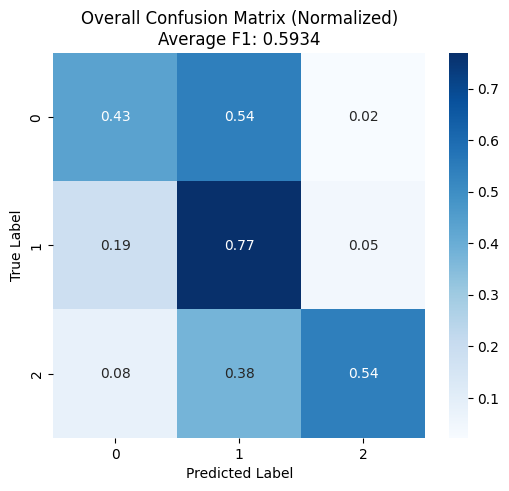


Cross-validation results
Fold F1s: [0.5939854211425439, 0.5515446033682897, 0.6298081066240521, 0.5983476939250534]
Mean Macro F1: 0.5934
Std Macro F1: 0.0278


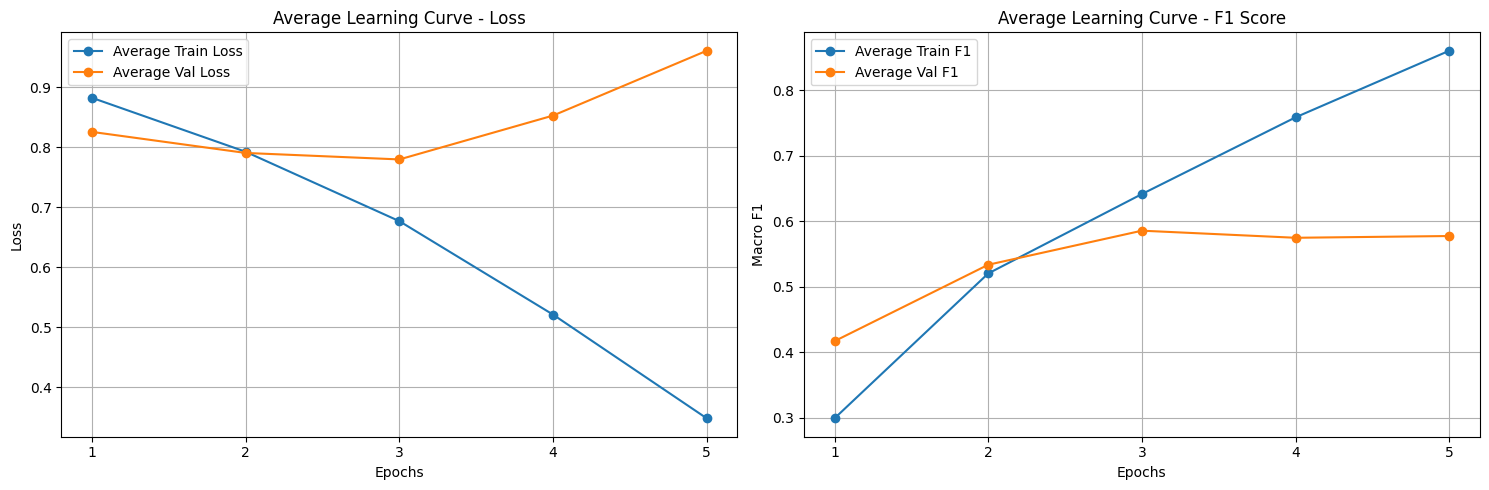

In [9]:

# ==========================================
#  Experiment 8
# ==========================================

n_splits = 4
num_epochs = 5 
batch_size = 4
learning_rate = 3e-5


# Metrics storage
history = {'train_loss': [], 'val_loss': [], 'train_f1': [], 'val_f1': []}
fold_results = []
# Out-Of-Fold predictions
oof_preds = []
oof_labels =[]

skf = StratifiedKFold(n_splits=n_splits, shuffle=True, random_state=42)
fold_times = []
experiment_start_time = time.time()
# ==========================================
#  Cross-Validation Loop
# ==========================================
# Loop over folds

for fold, (train_idx, val_idx) in enumerate(skf.split(df_train, df_train["labels"])):
    fold_start_time = time.time()
    print(f"\n Starting Fold {fold + 1}/{n_splits}")
    
    df_train_fold = df_train.iloc[train_idx]
    df_val_fold = df_train.iloc[val_idx]
#Tokenizer
    train_encodings = tokenizer(
        list(df_train_fold["question"]),
        list(df_train_fold["interview_answer"]),
        truncation=True,
        padding=True,
        max_length=512 
    )
    val_encodings = tokenizer(
        list(df_val_fold["question"]),
        list(df_val_fold["interview_answer"]),
        truncation=True,
        padding=True,
        max_length=512
    )
 
    train_dataset = ClarityDataset(train_encodings, df_train_fold["labels"].tolist())
    val_dataset = ClarityDataset(val_encodings, df_val_fold["labels"].tolist())

    train_loader = DataLoader(
        train_dataset,
        batch_size=batch_size,
        shuffle=True 
    )

    val_loader = DataLoader(
        val_dataset,
        batch_size=batch_size,
        shuffle=False # no shuffle here
    )
# model
    model = AutoModelForSequenceClassification.from_pretrained(model_checkpoint, num_labels=3)
# for 2 gpus
    if device_manager.use_data_parallel:
        model = torch.nn.DataParallel(model)
    model.to(device)
   #optimizer
    optimizer = AdamW(model.parameters(), lr=learning_rate)
# Cross-entropy loss for multiclass classification
    loss_fn = torch.nn.CrossEntropyLoss()
# Scheduler for gradually decreasing the learning rate
    num_training_steps = num_epochs * len(train_loader)
    lr_scheduler = get_scheduler(
        name="linear", 
        optimizer=optimizer, 
        num_warmup_steps=0,  
        num_training_steps=num_training_steps
    )

    # Store training and validation loss/F1 for each epoch in the current fold

    fold_train_loss, fold_val_loss = [], []
    fold_train_f1, fold_val_f1 = [], []
    # Keep the best validation F1 score for this fold

    best_f1_fold = 0
    best_preds_fold, best_labels_fold = [], []
    # Loop over epochs
    for epoch in range(num_epochs):
        model.train()     # Set the model to training mode
        total_train_loss = 0     # Reset training loss for each epoch

        train_preds, train_labels = [], []     # Store training predictions and labels for F1 calculation

        # Training loop over batches

        for batch in tqdm(train_loader, desc=f"Fold {fold+1} Epoch {epoch+1}"):
            
            optimizer.zero_grad()         # Clear previous gradients
           
            # Move batch data to device 

            input_ids = batch['input_ids'].to(device)
            attention_mask = batch['attention_mask'].to(device)
            labels = batch['labels'].to(device)
            # Forward pass
            outputs = model(input_ids, attention_mask=attention_mask)
           
            loss = loss_fn(outputs.logits, labels) # Compute loss
            loss.backward() # Backpropagation            
            optimizer.step()# Update model parameters
            lr_scheduler.step()# Update learning rate

            total_train_loss += loss.item() # Add batch loss to total training loss
            # Store predictions and true labels for this batch
            train_preds.extend(torch.argmax(outputs.logits, dim=1).cpu().numpy())
            train_labels.extend(labels.cpu().numpy())
        # Compute average training loss for the epoch
        avg_train_loss = total_train_loss / len(train_loader)
        # Compute training macro F1 score for the epoch
        avg_train_f1 = f1_score(train_labels, train_preds, average="macro")
        
        # Set the model to evaluation mode

        model.eval()
        total_val_loss = 0 # Reset validation loss for this epoch
        val_preds, val_labels = [], [] # Store validation predictions and labels for F1 calculation
       
        # Validation loop (no gradient computation)
        with torch.no_grad():
            for batch in val_loader:
                # Move batch data to device
                input_ids = batch['input_ids'].to(device)
                attention_mask = batch['attention_mask'].to(device)
                labels = batch['labels'].to(device)
                # Forward pass
                outputs = model(input_ids, attention_mask=attention_mask)
                loss = loss_fn(outputs.logits, labels) # Compute validation loss

                total_val_loss += loss.item()# Add batch loss to total validation loss
                # Store predictions and true labels
                val_preds.extend(torch.argmax(outputs.logits, dim=1).cpu().numpy())
                val_labels.extend(labels.cpu().numpy())

        avg_val_loss = total_val_loss / len(val_loader)
        avg_val_f1 = f1_score(val_labels, val_preds, average="macro")
        
        # Save training/validation metrics for this epoch

        fold_train_loss.append(avg_train_loss)
        fold_val_loss.append(avg_val_loss)
        fold_train_f1.append(avg_train_f1)
        fold_val_f1.append(avg_val_f1)

        if avg_val_f1 > best_f1_fold:
            best_f1_fold = avg_val_f1
            best_preds_fold = val_preds
            best_labels_fold = val_labels
        
            

        print(f"Epoch {epoch+1}: Train Loss {avg_train_loss:.4f} | Val Loss {avg_val_loss:.4f} | Val F1 {avg_val_f1:.4f}")

    history['train_loss'].append(fold_train_loss)
    history['val_loss'].append(fold_val_loss)
    history['train_f1'].append(fold_train_f1)
    history['val_f1'].append(fold_val_f1)
    fold_results.append(best_f1_fold)
    oof_preds.extend(best_preds_fold)
    oof_labels.extend(best_labels_fold)
    
    fold_time = time.time() - fold_start_time
    fold_times.append(fold_time)
    del model, optimizer
    torch.cuda.empty_cache()
# ==========================================
#  OVERALL RESULTS 
# ==========================================

print("\n" + "="*50)
print(" Overall Cross Validation Results  ")
print("="*50)

mean_f1 = np.mean(fold_results)
std_f1 = np.std(fold_results)

print(f"\nAverage Validation F1 Score: {mean_f1:.4f} ± {std_f1:.4f}")

print("\nFold execution times:")
for i, fold_time in enumerate(fold_times):
    print(f"Fold {i+1}: {fold_time/60:.2f} minutes")

total_time = time.time() - experiment_start_time
mean_fold_time = np.mean(fold_times)

print(f"\nTotal time for all {n_splits} folds: {total_time/60:.2f} minutes")
print(f"Average time per fold: {mean_fold_time/60:.2f} minutes")

print("\n Overall Classification Report (Out-Of-Fold Predictions):")
print(classification_report(oof_labels, oof_preds))

plt.figure(figsize=(6, 5))
cm_overall = confusion_matrix(oof_labels, oof_preds, normalize='true')
sns.heatmap(cm_overall, annot=True, cmap='Blues', fmt='.2f')
plt.title(f"Overall Confusion Matrix (Normalized)\nAverage F1: {mean_f1:.4f}")
plt.ylabel('True Label')
plt.xlabel('Predicted Label')
plt.show()

cv_results = plot_cv_learning_curves(history, fold_results, num_epochs)



#### Experiment 9

- **Number of folds:** 4
- **Number of epochs:** 4
- **Batch size:** 4
- **Learning rate:** 3 × 10⁻⁵
- **Optimizer:** AdamW
- **Loss function:** Cross-entropy loss with class weights `[1.3, 1.0, 1.5]`
- **Learning rate scheduler:** Linear scheduler with no warm-up steps
- **Primary evaluation metric:** Macro F1-score

This experiment combined longer training with a weighted loss function. The number of epochs was set to 4, and slightly less aggressive class weights were used in order to support the minority classes without excessively penalizing the majority class.


 Starting Fold 1/4
Class weights: [1.3 1.  1.5]


Loading weights:   0%|          | 0/100 [00:00<?, ?it/s]

DistilBertForSequenceClassification LOAD REPORT from: distilbert-base-uncased
Key                     | Status     | 
------------------------+------------+-
vocab_layer_norm.bias   | UNEXPECTED | 
vocab_projector.bias    | UNEXPECTED | 
vocab_transform.bias    | UNEXPECTED | 
vocab_transform.weight  | UNEXPECTED | 
vocab_layer_norm.weight | UNEXPECTED | 
classifier.bias         | MISSING    | 
pre_classifier.bias     | MISSING    | 
classifier.weight       | MISSING    | 
pre_classifier.weight   | MISSING    | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING	:those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


Fold 1 Epoch 1:   0%|          | 0/638 [00:00<?, ?it/s]

Epoch 1: Train Loss 0.9425 | Val Loss 0.9241 | Val F1 0.2501


...

Epoch 2: Train Loss 0.7918 | Val Loss 0.8430 | Val F1 0.5609


Fold 4 Epoch 3:   0%|          | 0/638 [00:00<?, ?it/s]

Epoch 3: Train Loss 0.6528 | Val Loss 0.8411 | Val F1 0.5700


Fold 4 Epoch 4:   0%|          | 0/638 [00:00<?, ?it/s]

Epoch 4: Train Loss 0.4534 | Val Loss 0.8916 | Val F1 0.5893

 Overall Cross Validation Results  

Average Validation F1 Score: 0.5940 ± 0.0137

Fold execution times:
Fold 1: 7.89 minutes
Fold 2: 7.88 minutes
Fold 3: 7.89 minutes
Fold 4: 7.89 minutes

Total time for all 4 folds: 31.55 minutes
Average time per fold: 7.89 minutes

 Overall Classification Report (Out-Of-Fold Predictions):
              precision    recall  f1-score   support

           0       0.53      0.47      0.50      1041
           1       0.70      0.76      0.72      2009
           2       0.61      0.52      0.56       352

    accuracy                           0.64      3402
   macro avg       0.61      0.58      0.59      3402
weighted avg       0.64      0.64      0.64      3402



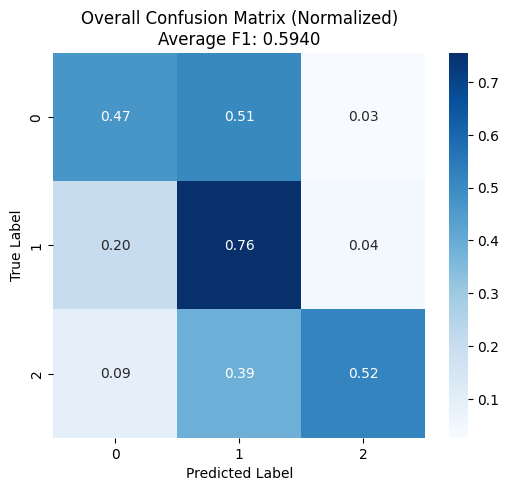


Cross-validation results
Fold F1s: [0.5942724293906766, 0.5772775724658674, 0.6150930878411786, 0.5892838133787156]
Mean Macro F1: 0.5940
Std Macro F1: 0.0137


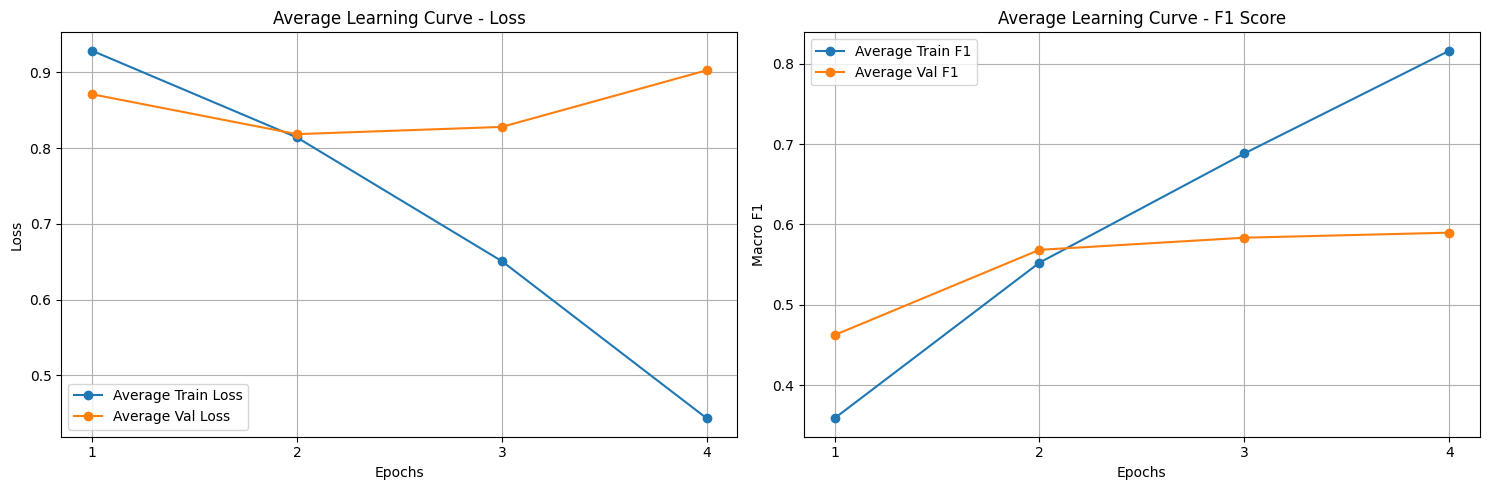

In [11]:

# ==========================================
#  Experiment 9
# ==========================================

n_splits = 4
num_epochs = 4 
batch_size = 4
learning_rate = 3e-5


# Metrics storage
history = {'train_loss': [], 'val_loss': [], 'train_f1': [], 'val_f1': []}
fold_results = []
# Out-Of-Fold predictions
oof_preds = []
oof_labels =[]

skf = StratifiedKFold(n_splits=n_splits, shuffle=True, random_state=42)
fold_times = []
experiment_start_time = time.time()
# ==========================================
#  Cross-Validation Loop
# ==========================================
# Loop over folds

for fold, (train_idx, val_idx) in enumerate(skf.split(df_train, df_train["labels"])):
    fold_start_time = time.time()
    print(f"\n Starting Fold {fold + 1}/{n_splits}")
    
    df_train_fold = df_train.iloc[train_idx]
    df_val_fold = df_train.iloc[val_idx]
#Tokenizer
    train_encodings = tokenizer(
        list(df_train_fold["question"]),
        list(df_train_fold["interview_answer"]),
        truncation=True, 
        padding=True,
        max_length=512  
    )
    val_encodings = tokenizer(
        list(df_val_fold["question"]),
        list(df_val_fold["interview_answer"]),
        truncation=True,
        padding=True,
        max_length=512
    )
 
    train_dataset = ClarityDataset(train_encodings, df_train_fold["labels"].tolist())
    val_dataset = ClarityDataset(val_encodings, df_val_fold["labels"].tolist())

    train_loader = DataLoader(
        train_dataset,
        batch_size=batch_size,
        shuffle=True 
    )

    val_loader = DataLoader(
        val_dataset,
        batch_size=batch_size,
        shuffle=False # no shuffle here
    )
    # class weights
    class_weights = torch.tensor([1.3,1,1.5] , dtype=torch.float).to(device)
    print("Class weights:", class_weights.detach().cpu().numpy())

    # model
    model = AutoModelForSequenceClassification.from_pretrained(model_checkpoint, num_labels=3)
    # for 2 gpus
    if device_manager.use_data_parallel:
        model = torch.nn.DataParallel(model)
    model.to(device)
   #optimizer
    optimizer = AdamW(model.parameters(), lr=learning_rate)
# Cross-entropy loss for multiclass classification and class weights
    loss_fn = torch.nn.CrossEntropyLoss(weight=class_weights)
# Scheduler for gradually decreasing the learning rate
    num_training_steps = num_epochs * len(train_loader)
    lr_scheduler = get_scheduler(
        name="linear", 
        optimizer=optimizer, 
        num_warmup_steps=0,  
        num_training_steps=num_training_steps
    )

    # Store training and validation loss/F1 for each epoch in the current fold

    fold_train_loss, fold_val_loss = [], []
    fold_train_f1, fold_val_f1 = [], []
    # Keep the best validation F1 score for this fold

    best_f1_fold = 0
    best_preds_fold, best_labels_fold = [], []
    # Loop over epochs
    for epoch in range(num_epochs):
        model.train()     # Set the model to training mode
        total_train_loss = 0     # Reset training loss for each epoch

        train_preds, train_labels = [], []     # Store training predictions and labels for F1 calculation

        # Training loop over batches

        for batch in tqdm(train_loader, desc=f"Fold {fold+1} Epoch {epoch+1}"):
            
            optimizer.zero_grad()         # Clear previous gradients
           
            # Move batch data to device 

            input_ids = batch['input_ids'].to(device)
            attention_mask = batch['attention_mask'].to(device)
            labels = batch['labels'].to(device)
            # Forward pass
            outputs = model(input_ids, attention_mask=attention_mask)

            loss = loss_fn(outputs.logits, labels) # Compute loss
            loss.backward() # Backpropagation            
            optimizer.step()# Update model parameters
            lr_scheduler.step()# Update learning rate

            total_train_loss += loss.item() # Add batch loss to total training loss
            # Store predictions and true labels for this batch
            train_preds.extend(torch.argmax(outputs.logits, dim=1).cpu().numpy())
            train_labels.extend(labels.cpu().numpy())
        # Compute average training loss for the epoch
        avg_train_loss = total_train_loss / len(train_loader)
        # Compute training macro F1 score for the epoch
        avg_train_f1 = f1_score(train_labels, train_preds, average="macro")
        
        # Set the model to evaluation mode

        model.eval()
        total_val_loss = 0 # Reset validation loss for this epoch
        val_preds, val_labels = [], [] # Store validation predictions and labels for F1 calculation
       
        # Validation loop (no gradient computation)
        with torch.no_grad():
            for batch in val_loader:
                # Move batch data to device
                input_ids = batch['input_ids'].to(device)
                attention_mask = batch['attention_mask'].to(device)
                labels = batch['labels'].to(device)
                # Forward pass
                outputs = model(input_ids, attention_mask=attention_mask)
                loss = loss_fn(outputs.logits, labels) # Compute validation loss

                total_val_loss += loss.item()# Add batch loss to total validation loss
                # Store predictions and true labels
                val_preds.extend(torch.argmax(outputs.logits, dim=1).cpu().numpy())
                val_labels.extend(labels.cpu().numpy())

        avg_val_loss = total_val_loss / len(val_loader)
        avg_val_f1 = f1_score(val_labels, val_preds, average="macro")
        
        # Save training/validation metrics for this epoch

        fold_train_loss.append(avg_train_loss)
        fold_val_loss.append(avg_val_loss)
        fold_train_f1.append(avg_train_f1)
        fold_val_f1.append(avg_val_f1)

        if avg_val_f1 > best_f1_fold:
            best_f1_fold = avg_val_f1
            best_preds_fold = val_preds
            best_labels_fold = val_labels
        
            

        print(f"Epoch {epoch+1}: Train Loss {avg_train_loss:.4f} | Val Loss {avg_val_loss:.4f} | Val F1 {avg_val_f1:.4f}")

    history['train_loss'].append(fold_train_loss)
    history['val_loss'].append(fold_val_loss)
    history['train_f1'].append(fold_train_f1)
    history['val_f1'].append(fold_val_f1)
    fold_results.append(best_f1_fold)
    oof_preds.extend(best_preds_fold)
    oof_labels.extend(best_labels_fold)
    
    fold_time = time.time() - fold_start_time
    fold_times.append(fold_time)
    del model, optimizer
    torch.cuda.empty_cache()
# ==========================================
#  OVERALL RESULTS 
# ==========================================

print("\n" + "="*50)
print(" Overall Cross Validation Results  ")
print("="*50)

mean_f1 = np.mean(fold_results)
std_f1 = np.std(fold_results)

print(f"\nAverage Validation F1 Score: {mean_f1:.4f} ± {std_f1:.4f}")

print("\nFold execution times:")
for i, fold_time in enumerate(fold_times):
    print(f"Fold {i+1}: {fold_time/60:.2f} minutes")

total_time = time.time() - experiment_start_time
mean_fold_time = np.mean(fold_times)

print(f"\nTotal time for all {n_splits} folds: {total_time/60:.2f} minutes")
print(f"Average time per fold: {mean_fold_time/60:.2f} minutes")

print("\n Overall Classification Report (Out-Of-Fold Predictions):")
print(classification_report(oof_labels, oof_preds))

plt.figure(figsize=(6, 5))
cm_overall = confusion_matrix(oof_labels, oof_preds, normalize='true')
sns.heatmap(cm_overall, annot=True, cmap='Blues', fmt='.2f')
plt.title(f"Overall Confusion Matrix (Normalized)\nAverage F1: {mean_f1:.4f}")
plt.ylabel('True Label')
plt.xlabel('Predicted Label')
plt.show()

cv_results = plot_cv_learning_curves(history, fold_results, num_epochs)



#### Conclusion

The epoch experiments showed that extending training can slightly improve the final macro F1-score, but it also increases the risk of overfitting. In Experiment 8, using 5 epochs with the non-weighted configuration achieved a mean macro F1-score of **0.5934**, which is almost identical to Experiment 4 (**0.5933**). Although this is a small improvement, the validation loss starts to increase in later epochs, indicating that the model begins to overfit.

Experiment 9, which combined 4 epochs with weighted loss, achieved the best overall result of this notebook, with a mean macro F1-score of **0.5940** and a standard deviation of **0.0137**. Compared with Experiment 4, this setup also reduced the number of misclassified samples for the minority classes. More specifically, the misclassified samples decreased from **61 to 51** for one minority class and from **43 to 39** for the other minority class.

However, the improvement in macro F1-score over Experiment 4 is very small. Therefore, this result should be interpreted as a marginal improvement rather than a major performance gain. Overall, the best DistilBERT configuration was Experiment 9, using batch size 4, learning rate $3 \times 10^{-5}$, 4 epochs, and class weights `[1.3, 1.0, 1.5]`.

##  Summary

| Experiment | Configuration | Mean Macro F1 |
|---|---|---:|
| Experiment 1 | Baseline: batch size 8, learning rate 2e-5 | 0.5772 |
| Experiment 2 | Batch size 8, learning rate 3e-5 | 0.5853 |
| Experiment 3 | Batch size 4, learning rate 2e-5 | 0.5832 |
| Experiment 4 | Batch size 4, learning rate 3e-5 | 0.5933 |
| Experiment 5 | Batch size 16, learning rate 3e-5 | 0.5657 |
| Experiment 6 | Weighted loss `[1.4, 1.0, 1.5]` | 0.5890 |
| Experiment 7 | Striding window + warm-up scheduler | 0.5619 |
| Experiment 8 | 5 epochs | 0.5934 |
| Experiment 9 | 4 epochs + weighted loss `[1.3, 1.0, 1.5]` | 0.5940 |

The best result was obtained in Experiment 9, which achieved a mean macro F1-score of **0.5940**. This setup combined batch size 4, learning rate $3 \times 10^{-5}$, 4 training epochs, and weighted Cross-Entropy Loss with class weights `[1.3, 1.0, 1.5]`.

Compared with Experiment 4, which achieved **0.5933**, the improvement in macro F1-score is very small. However, the confusion matrix shows that Experiment 9 separates the minority classes slightly better. More specifically, the number of misclassified samples decreased from **61 to 51** for one minority class and from **43 to 39** for the other minority class. This indicates that the weighted loss and additional training helped the model recover a few more minority-class instances.

Overall, although the performance gain over Experiment 4 is marginal, Experiment 9 provides a slightly better balance between overall macro F1-score and minority-class classification. In addition, DistilBERT achieved a performance very close to the regular BERT model, with only a slightly lower macro F1-score. This suggests that DistilBERT can provide comparable results while remaining a lighter and faster model to train. However, its final performance is still slightly limited on this classification task.